<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Evaluating Agentic Harnesses</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

This notebook continues **`03 - Advanced Agentic Harness.ipynb`**. There we upgraded the basic agentic loop with production-shaped primitives: typed tools, DAG planning, parallel execution, multi-tier memory, a verification hierarchy, multi-dimensional budgets, and structured tracing.

Here we put that harness to work. All of the primitives from notebook 03 have been factored out into the standalone module **`d4sci_harness.py`** — this notebook *imports* the harness instead of rebuilding it, which is exactly how you would consume it in a real project.

## Table of contents

1. Setup: harness module and backend
2. A mini eval harness
3. Visualizing eval results
4. Enhanced features: re-planning, real embeddings, and specialized workers
5. What we built and what's next

In [1]:
from typing import Callable
import asyncio
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from IPython.display import Image

import nest_asyncio
import watermark

# The advanced agentic harness from notebook 03, as a standalone module
import d4sci_harness as dh
from d4sci_harness import (
    AnthropicProvider, MockProvider,
    TypedTool, TOOLS,
    PlanDAG, PlanNode, NodeStatus, MAX_CONCURRENT,
    MemoryStore, USE_REAL_EMBEDDINGS,
    Orchestrator,
)

# Required in Jupyter so asyncio.run() works inside an already-running event loop
nest_asyncio.apply()

%load_ext watermark
%matplotlib inline

We print the versions of the libraries we use, for future reference.

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 7e479ea973992ae3c95c6e486200cb1c64cca08b

IPython     : 9.12.0
matplotlib  : 3.10.8
nest_asyncio: 1.6.0
numpy       : 2.4.4
watermark   : 2.6.0



Load the default figure style.

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

---
## 1. Setup: harness module and backend

Everything built step-by-step in notebook 03 — providers, typed tools, the plan DAG, the parallel executor, memory, verification, budgets, tracing, and the `Orchestrator` — now lives in **`d4sci_harness.py`**. The module is import-for-import identical to the notebook code, so anything unclear here can be cross-referenced against the full rationale there.

As before, the harness runs against either backend:

| Backend | When to use | Requirements |
|---|---|---|
| **`mock`** | Teaching, CI, debugging harness logic | None — fully offline |
| **`anthropic`** | Realistic planner/summarizer/critic behavior | `ANTHROPIC_API_KEY` in environment |

`dh.set_provider()` switches the backend for the whole module — including the LLM-backed tools (`summarize_city`, `aggregate_report`), which read the module-level provider. The harness code path is identical either way.

In [4]:
# Pick a backend. Use "mock" for offline/deterministic runs; "anthropic" needs ANTHROPIC_API_KEY.
BACKEND = "anthropic"

llm = dh.set_provider(BACKEND)

# Memory store + orchestrator, exactly as assembled at the end of notebook 03
store = MemoryStore()
orch = Orchestrator(provider=llm, tools=TOOLS, memory=store)

print("Provider:", type(llm).__name__)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MemoryStore: Using sentence-transformers embeddings (all-MiniLM-L6-v2)
Provider: AnthropicProvider


---
## 2. A mini eval harness

### Why eval matters

A single successful demo proves the harness *can* work. An **eval suite** proves it *usually* works — and quantifies **cost** and **latency** when it doesn't.

This is the smallest useful eval unit:

```
for task in EVAL_SUITE:
    result = orchestrator.run(task.goal, task.required_cities)
    record(pass/fail, tokens, cost, status)
aggregate → pass_rate, avg_cost, avg_latency
```

### What we're measuring

| Metric | Why |
|---|---|
| **Pass rate** | Functional correctness across tasks |
| **Token usage** | Cost predictability |
| **Status codes** | Failure mode distribution (`failed_execute` vs `failed_verify` vs `budget`) |
| **Replan count** | Robustness to bad inputs |

The suite below has three well-posed tasks and one adversarial one: the last task asks for **Atlantis**, a city that doesn't exist in `CITY_FACTS`. It's there to measure the recovery path, not just the happy path — note that we only *require* the cities that can actually be satisfied.

Without this loop, every harness change is a manual re-run and a gut feel. With it, you can regression-test before merging.

In [5]:
EVAL_SUITE = [
    {
        "goal": "Build a comparison report of Paris, Tokyo, and New York.",
        "required_cities": ["paris", "tokyo", "new york"],
    },
    {
        "goal": "Build a comparison report of London and Sydney.",
        "required_cities": ["london", "sydney"],
    },
    {
        "goal": "Build a comparison report of Paris and London.",
        "required_cities": ["paris", "london"],
    },
    {
        # Atlantis is not in CITY_FACTS — this task exercises the re-planning
        # path, so we only require the city that can actually be satisfied
        "goal": "Build a comparison report of Paris and Atlantis.",
        "required_cities": ["paris"],
    },
]


async def run_eval(orch: Orchestrator, suite: list[dict]) -> tuple[list[dict], list]:
    """Run every task in the suite, returning summary rows and full RunResults."""
    rows, runs = [], []
    for task in suite:
        res = await orch.run(task["goal"], task["required_cities"])
        runs.append(res)
        rows.append({
            "goal":       task["goal"][:60],
            "passed":     bool(res.verdict and res.verdict.passed),
            "status":     res.status,
            "replans":    res.replan_count,
            "tokens":     res.budget.tokens_used,
            "tool_calls": res.budget.tool_calls_used,
            "elapsed_s":  round(res.budget.elapsed(), 3),
            "cost_usd":   round(res.budget.cost_usd, 5),
            "tier":       res.verdict.tier if res.verdict else "n/a",
        })
    return rows, runs


eval_rows, eval_runs = asyncio.run(run_eval(orch, EVAL_SUITE))

print(f"{'goal':44s} {'passed':6s} {'status':26s} {'replans':7s} "
      f"{'tokens':6s} {'elapsed_s':9s} {'cost_usd':8s} {'tier'}")
for r in eval_rows:
    print(f"{r['goal'][:44]:44s} {str(r['passed']):6s} {r['status']:26s} "
          f"{r['replans']:^7d} {r['tokens']:6d} {r['elapsed_s']:9.2f} "
          f"{r['cost_usd']:8.5f} {r['tier']}")

pass_rate = sum(r["passed"] for r in eval_rows) / len(eval_rows)
avg_tokens = sum(r["tokens"] for r in eval_rows) / len(eval_rows)
avg_cost = sum(r["cost_usd"] for r in eval_rows) / len(eval_rows)
print(f"\nAggregate: pass_rate={pass_rate:.0%}  avg_tokens={avg_tokens:.0f}  "
      f"avg_cost=${avg_cost:.4f}")

goal                                         passed status                     replans tokens elapsed_s cost_usd tier
Build a comparison report of Paris, Tokyo, a True   ok                            0      1219      8.04  0.00366 llm_judge
Build a comparison report of London and Sydn True   ok                            0       950      7.04  0.00285 llm_judge
Build a comparison report of Paris and Londo True   ok                            0       949      6.17  0.00285 llm_judge
Build a comparison report of Paris and Atlan False  failed_verify_replanned_1x    1      1236      8.27  0.00371 llm_judge

Aggregate: pass_rate=75%  avg_tokens=1088  avg_cost=$0.0033


### Interpreting eval results

The eval loop runs each task independently and prints one summary row per task. Read it like a CI dashboard:

- **Pass rate < 100%** — expected with the real LLM backend (non-deterministic plans). With `mock`, you should see the well-posed tasks at 100%.
- **`status` column** — distinguishes bad output (`failed_verify`) from bad planning/execution (`failed_execute`)
- **`replans ≥ 1` on the Atlantis task** — confirms the recovery path fires; whether the amended plan then passes verification depends on what the planner produced
- **Avg tokens / cost** — the baseline for regression: a harness change that doubles cost without improving pass rate is a red flag

This is intentionally minimal. Production evals add per-tier verifier stats, p95 latency, and golden-file diffs — but the *shape* is identical.

### Beyond this mini harness

In a real project you'd extend the eval loop with:

- **Robustness** — same task with adversarial inputs (unknown cities, typos, prompt injection in tool outputs)
- **Safety** — policy violations across the suite (PII leakage, unauthorized tool calls)
- **Regression baselines** — compare today's pass rate and p95 latency against yesterday's before merging harness changes
- **Human eval spot-checks** — LLM judges can miss subtle errors; sample 5% for human review

The architecture we've built makes these additions straightforward: new checks plug into the verification hierarchy; new tasks plug into `EVAL_SUITE`; new metrics plug into `TraceEvent`.


---
## 3. Visualizing eval results

The table above answers *did it pass?* — the plots below answer the operational questions that follow: what did each run cost, where did the wall-clock time go, and how close did each run come to its budget ceiling. Everything is built from the `RunResult` objects the eval loop already collected — no extra instrumentation, just views over the trace.

Two conventions, carried over from notebook 03:

- **Roles keep their colors everywhere** — planner, worker, and critic are always drawn with the same three colors
- **Outcome is never encoded by color alone** — pass/fail bars are also annotated with the final status and the verification tier that produced the verdict

In [6]:
# Shared conventions for the eval plots
task_labels = [t["goal"].removeprefix("Build a comparison report of ").rstrip(".")
               for t in EVAL_SUITE]

role_colors = {"planner": colors[0], "worker": colors[1], "critic": colors[2]}
outcome_colors = {True: colors[2], False: colors[5]}

y_pos = np.arange(len(EVAL_SUITE))

## Plot 1: cost per task, colored by outcome

Each bar is one eval task. The annotation carries the final status and the verification tier — `deterministic` checks are free, `llm_judge` verdicts cost tokens, and `n/a` means the run never produced a report to verify.

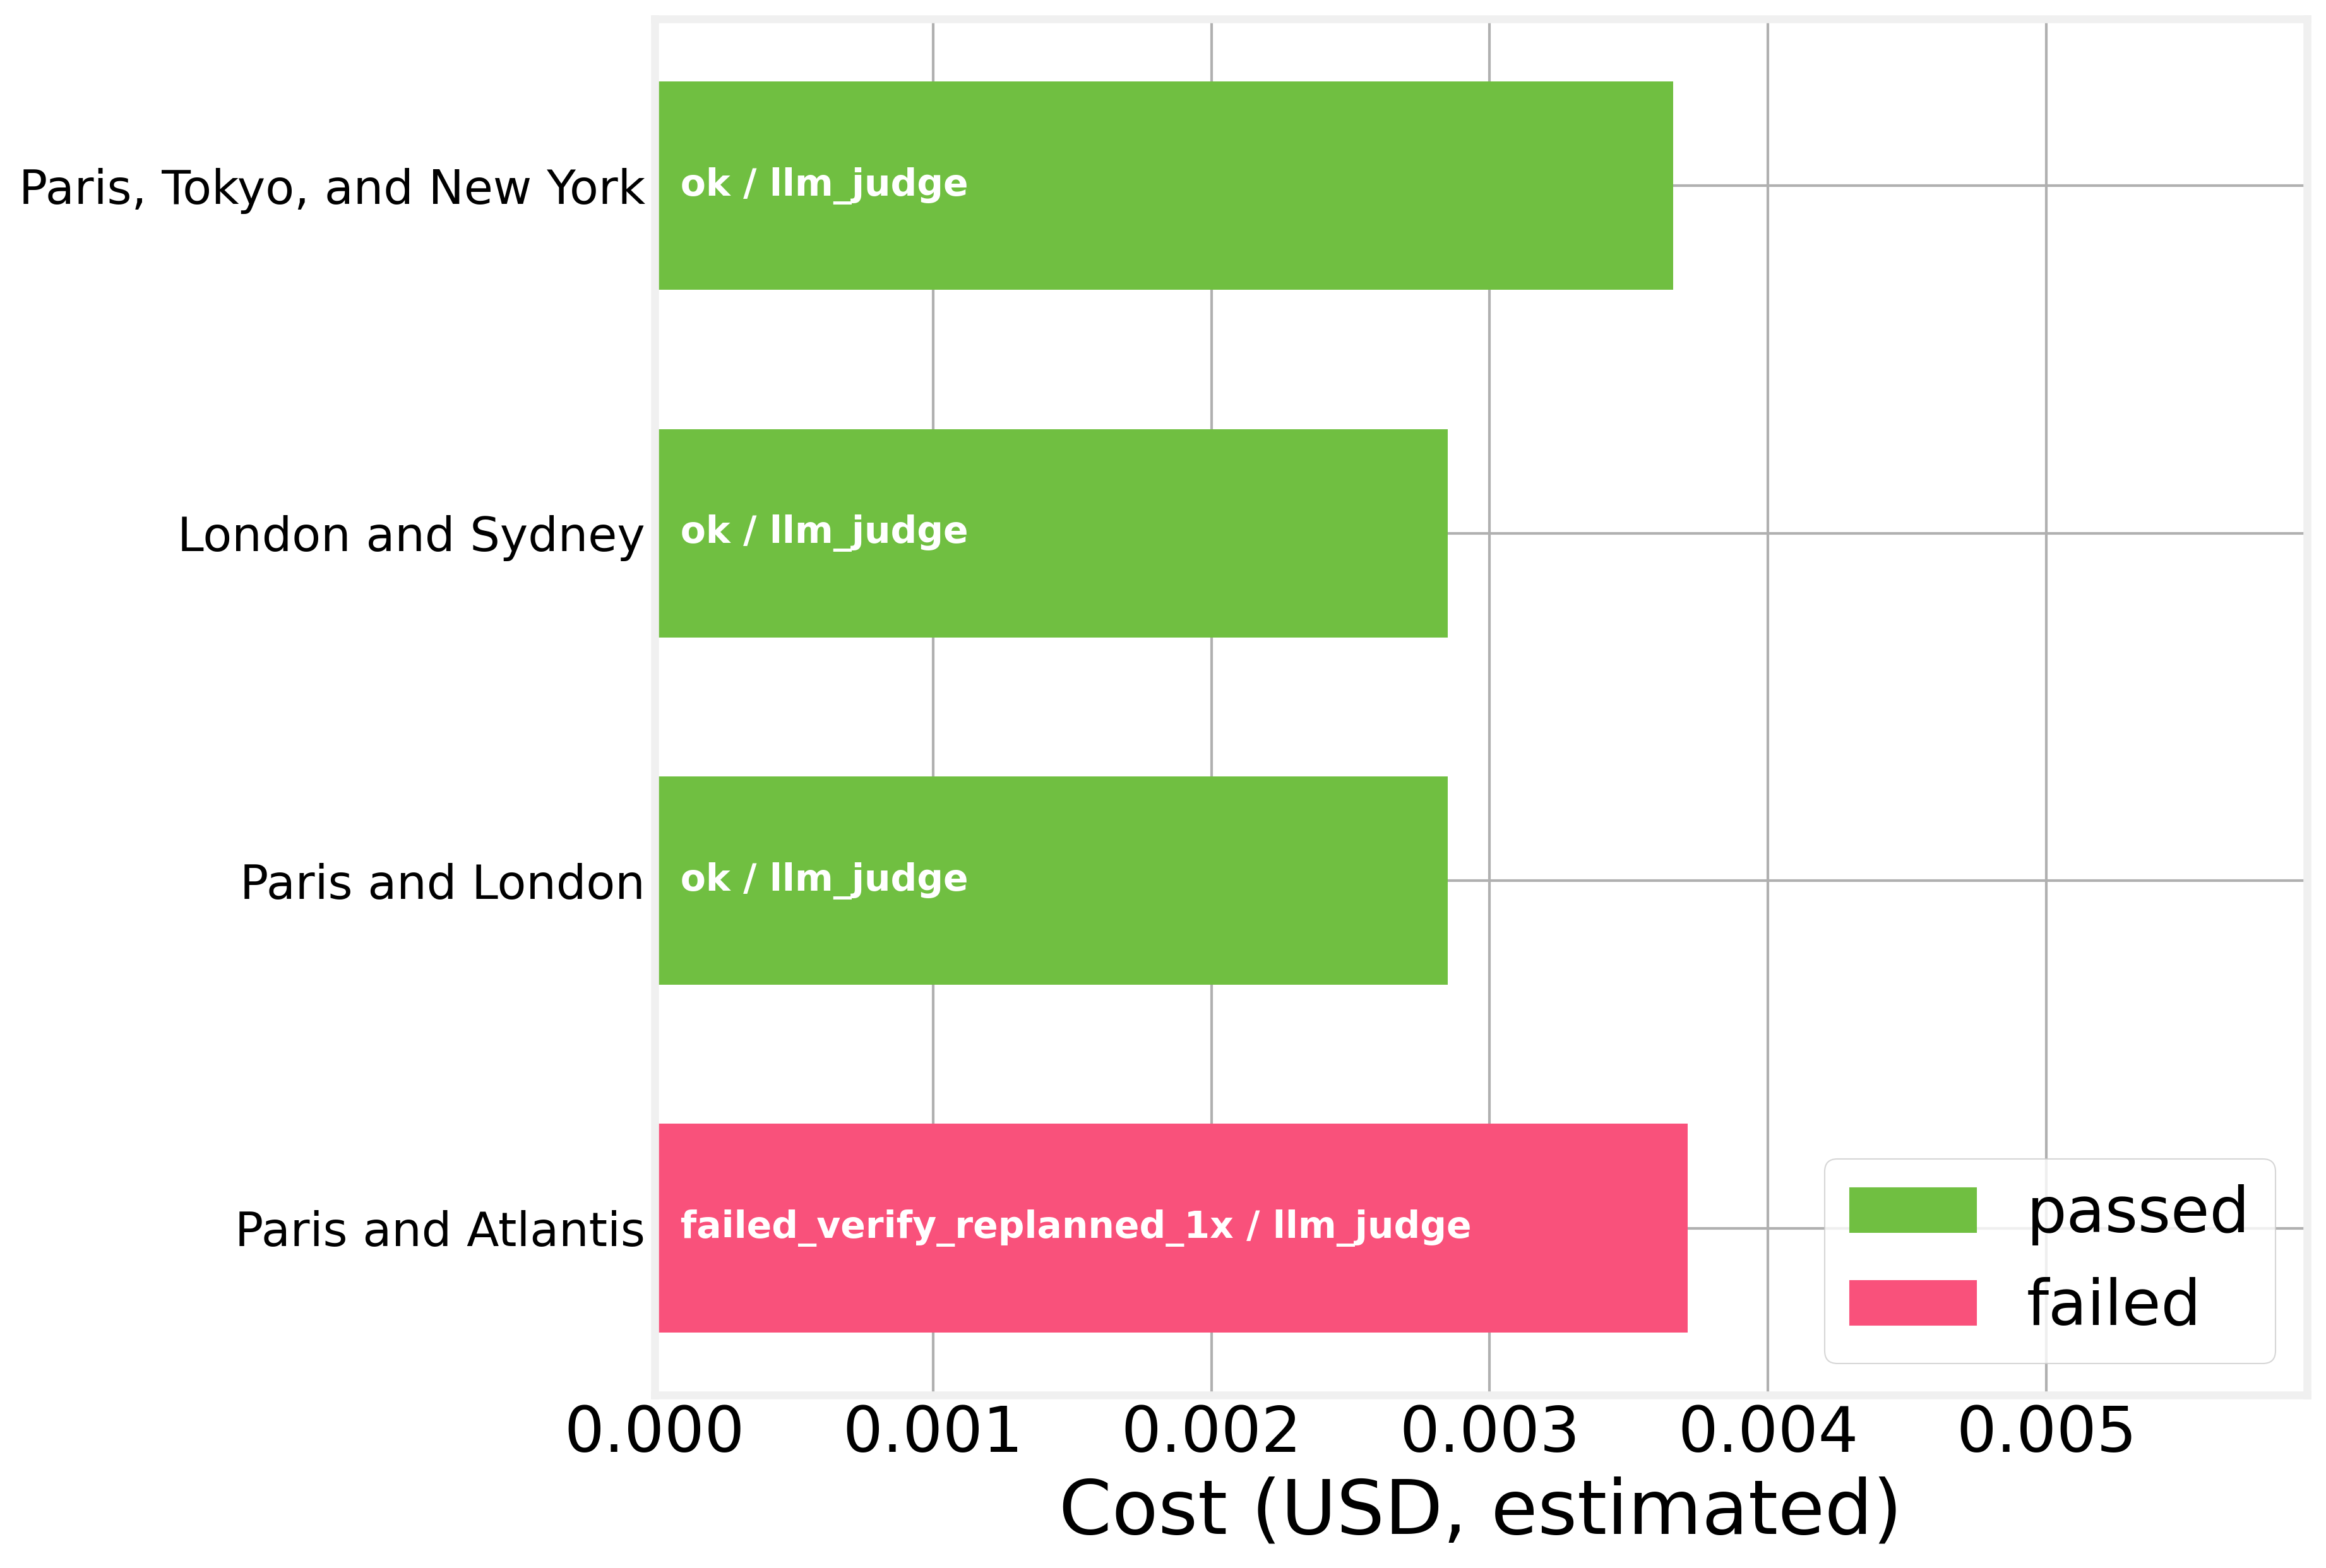

In [7]:
costs = [r["cost_usd"] for r in eval_rows]

fig, ax = plt.subplots()
ax.barh(y_pos, costs, height=0.6,
        color=[outcome_colors[r["passed"]] for r in eval_rows])
for y, r in zip(y_pos, eval_rows):
    ax.annotate(f"  {r['status']} / {r['tier']}", (0, y), va="center",
                fontsize=14, color="white", fontweight="bold")
ax.set_yticks(y_pos)
ax.set_yticklabels(task_labels, fontsize=18)
ax.invert_yaxis()
ax.set_xlabel("Cost (USD, estimated)")
ax.set_xlim(0, max(costs) * 1.6)  # keep the lower-right corner free for the legend
handles = [plt.Rectangle((0, 0), 1, 1, color=outcome_colors[k]) for k in (True, False)]
ax.legend(handles, ["passed", "failed"], loc="lower right")
plt.tight_layout()

## Plot 2: where the wall-clock time goes

The stacked segments sum the **per-step latency** by role — the total *serial* work each run performed. The gray diamond marks the run's actual **wall-clock** time. Whenever the stacked bar extends past the diamond, the DAG executor was running steps in parallel — that gap is the parallelism payoff.

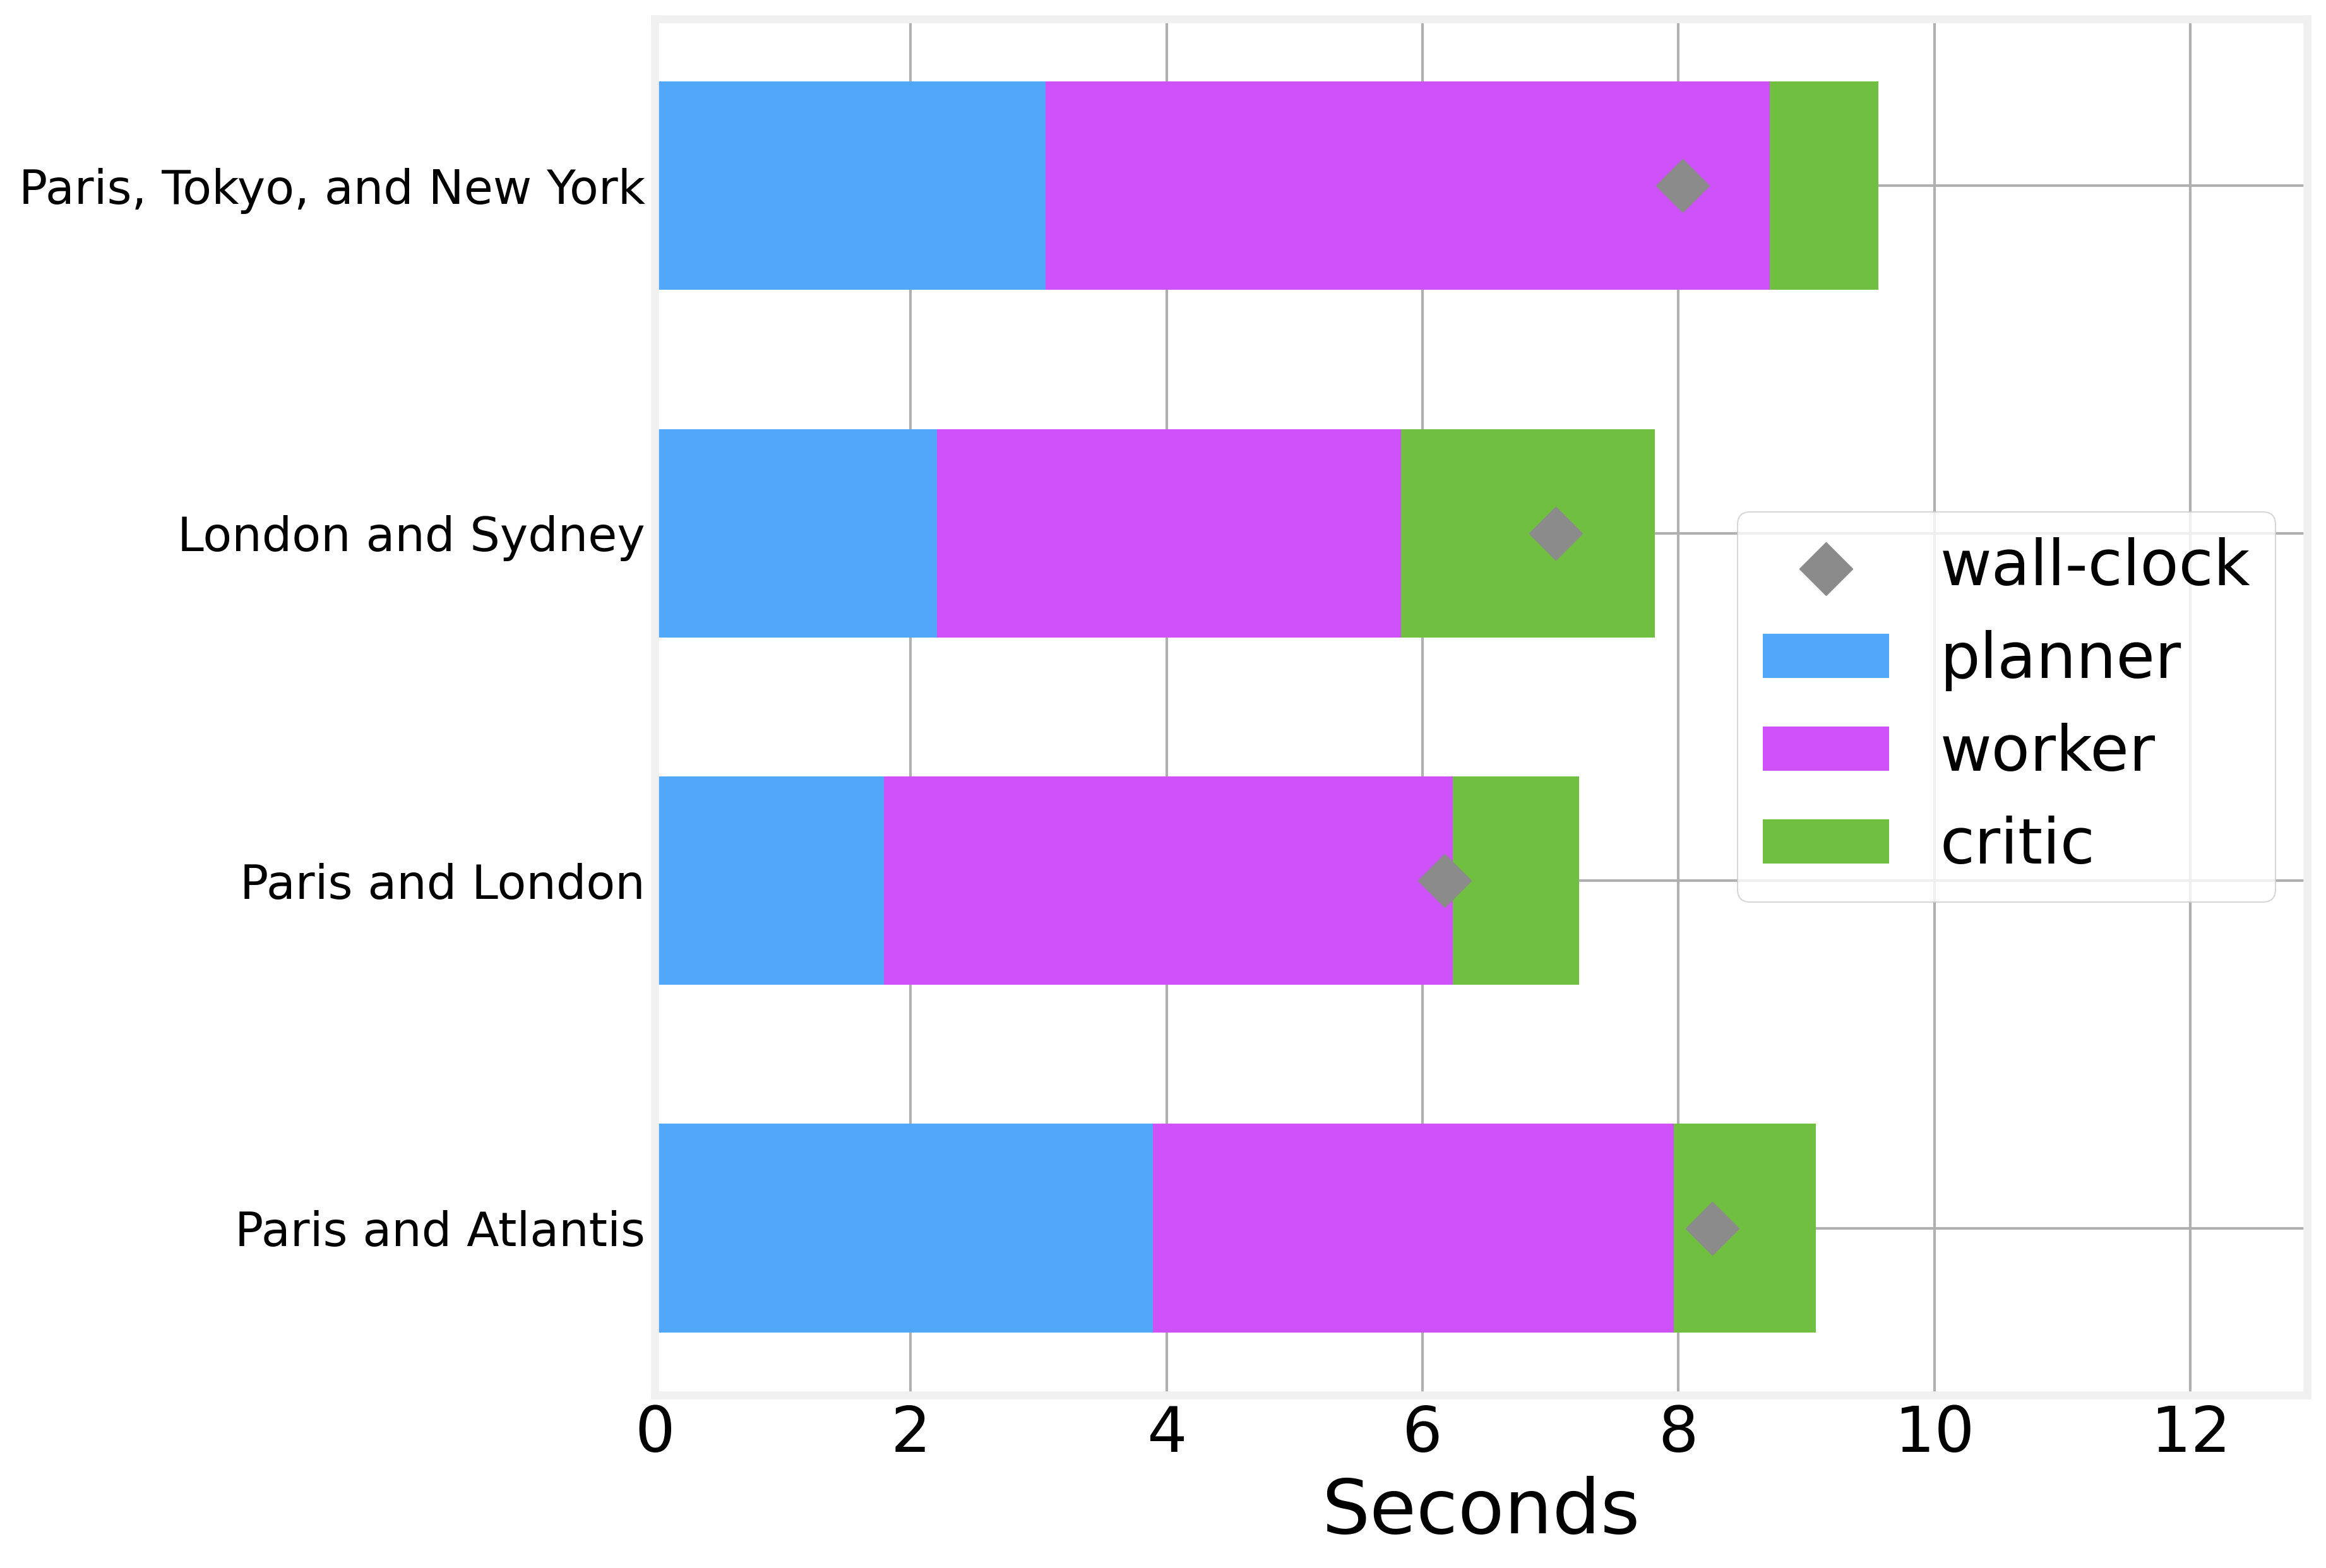

In [8]:
role_seconds = []
for run in eval_runs:
    per_role = {role: 0.0 for role in role_colors}
    for e in run.tracer.events:
        per_role[e.role] = per_role.get(e.role, 0.0) + e.latency_ms / 1000
    role_seconds.append(per_role)

fig, ax = plt.subplots()
left = np.zeros(len(eval_runs))
for role, color in role_colors.items():
    widths = np.array([s[role] for s in role_seconds])
    ax.barh(y_pos, widths, left=left, height=0.6, color=color, label=role)
    left += widths
ax.scatter([r["elapsed_s"] for r in eval_rows], y_pos, marker="D", s=200,
           color=colors[7], zorder=3, label="wall-clock")
ax.set_yticks(y_pos)
ax.set_yticklabels(task_labels, fontsize=18)
ax.invert_yaxis()
ax.set_xlabel("Seconds")
ax.set_xlim(0, max(left.max(), max(r["elapsed_s"] for r in eval_rows)) * 1.35)
ax.legend(loc="center right")
plt.tight_layout()

## Plot 3: tokens by role

The same breakdown for the token budget. Re-planning shows up as a wider planner segment; a report-heavy task shows up as a wider worker segment. If a harness change silently doubles the planner share without improving pass rate, this plot catches it.

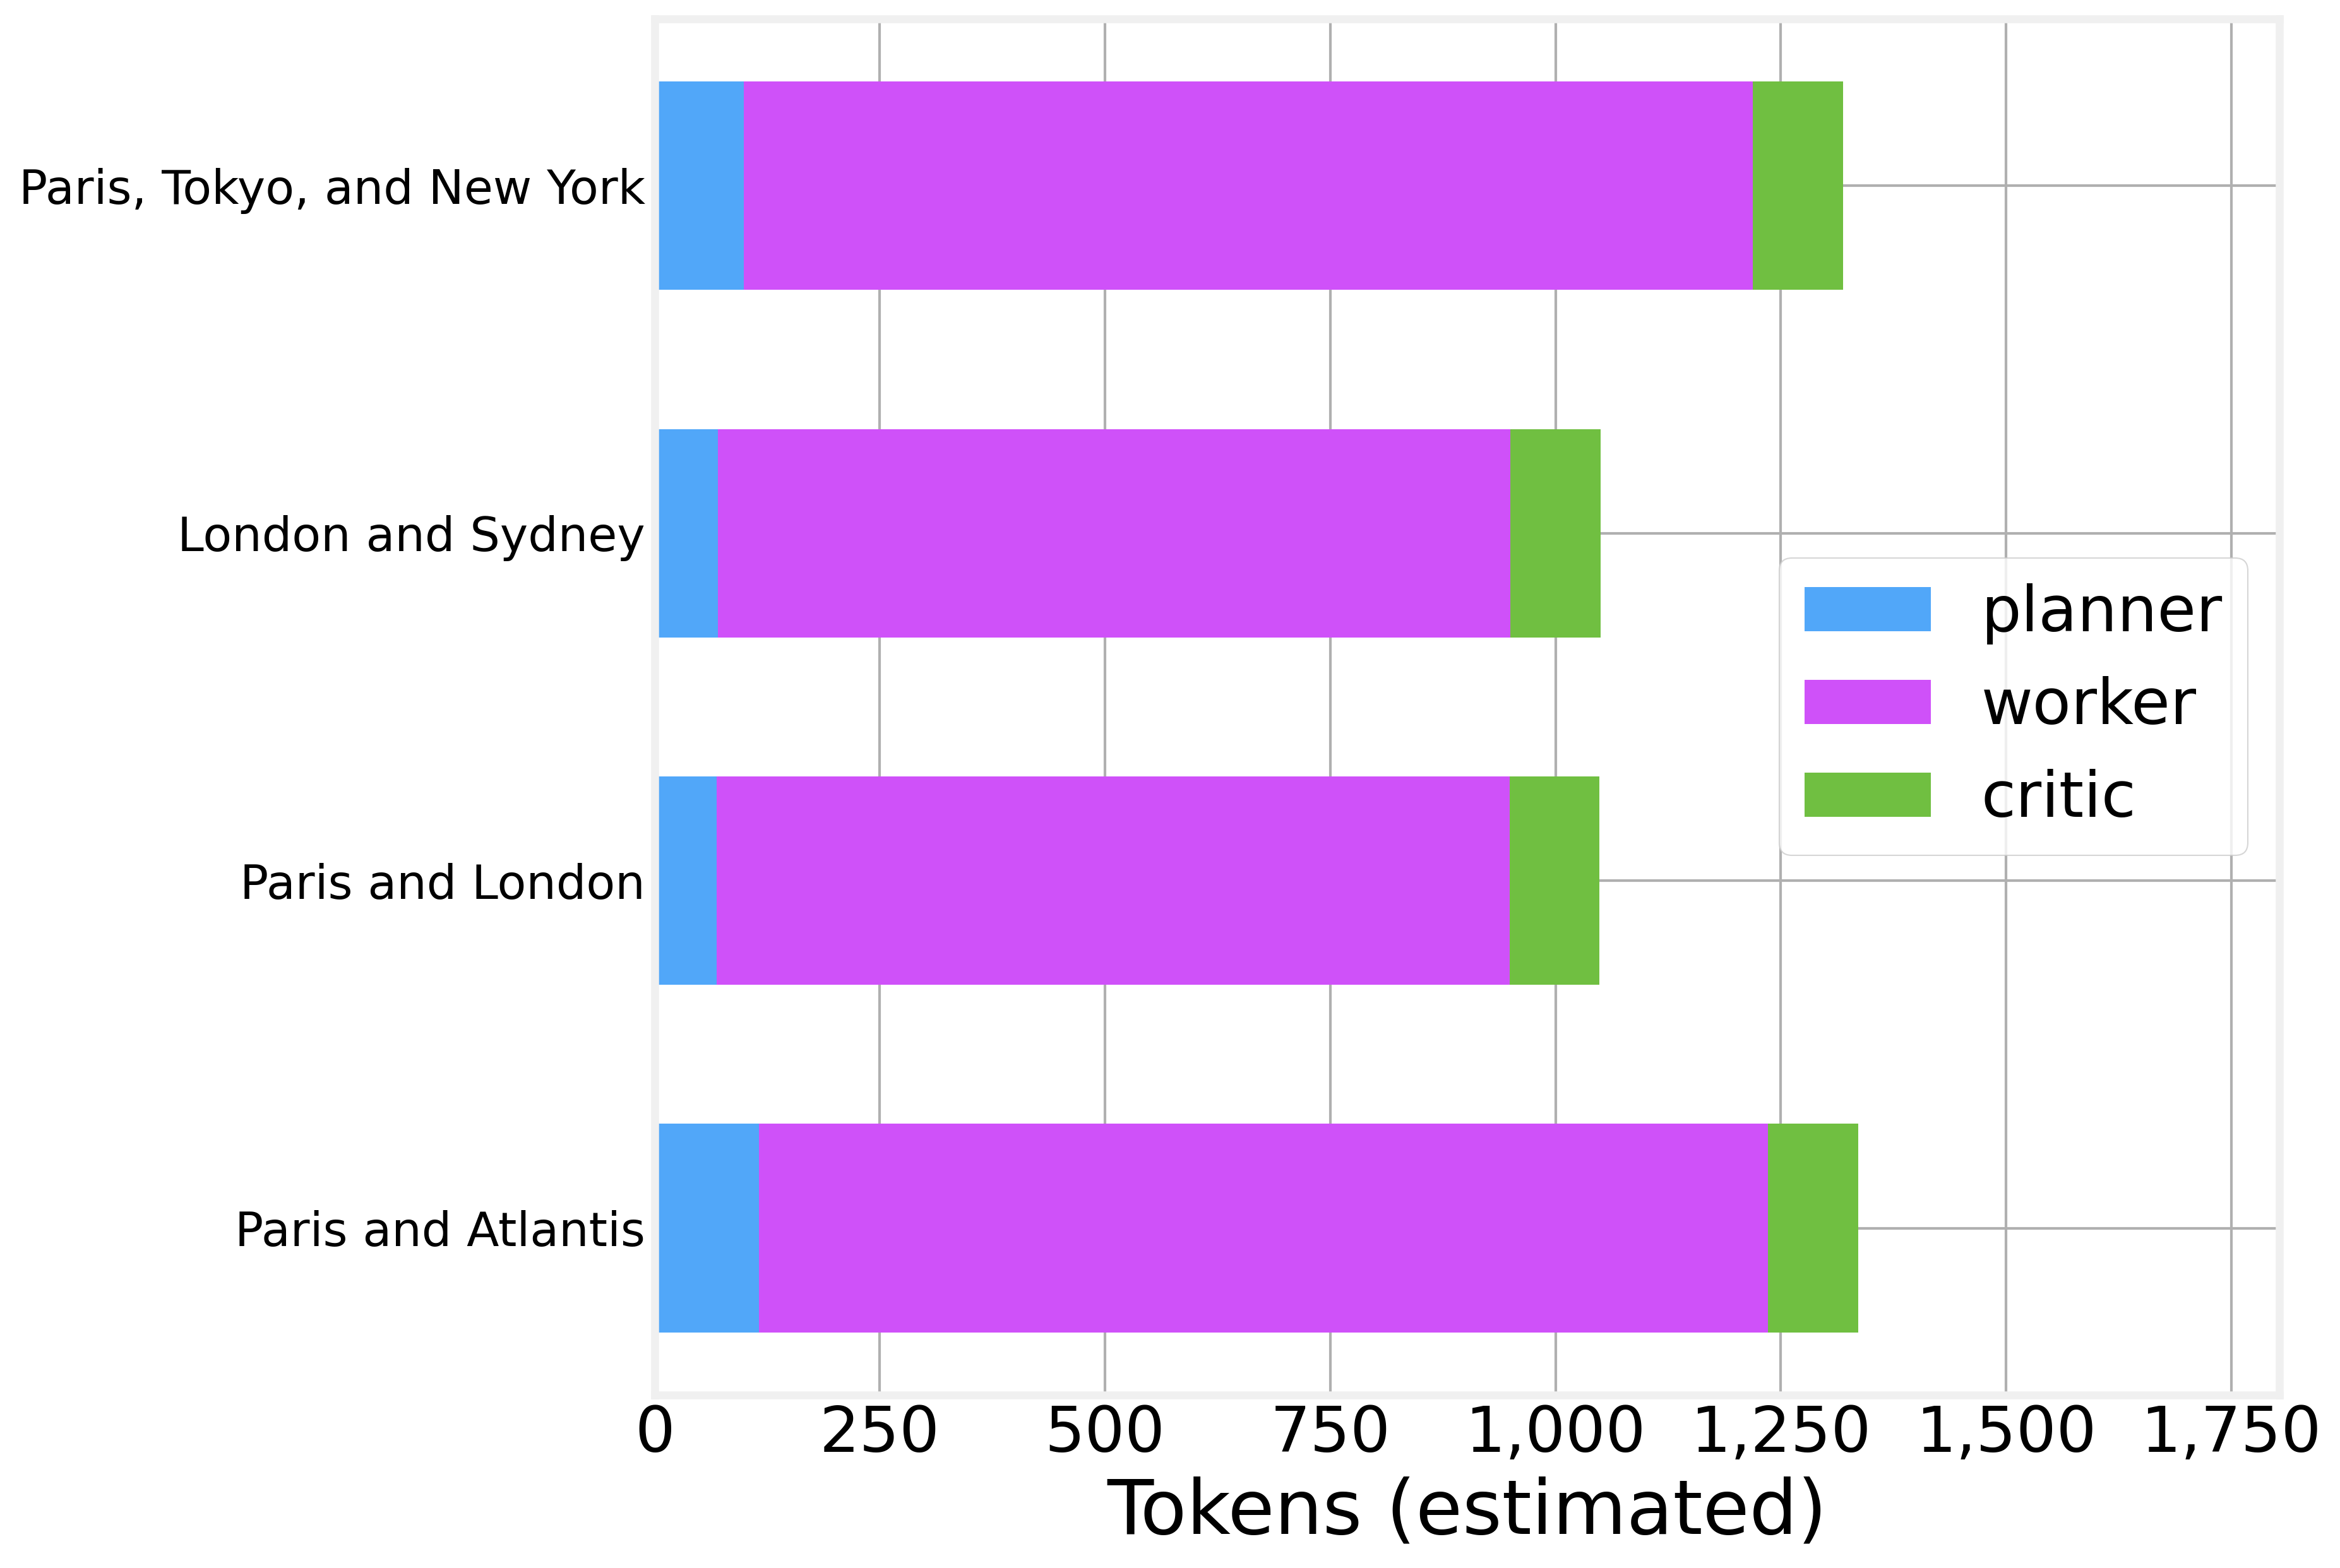

In [9]:
role_tokens = []
for run in eval_runs:
    per_role = {role: 0 for role in role_colors}
    for e in run.tracer.events:
        per_role[e.role] = per_role.get(e.role, 0) + e.tokens
    role_tokens.append(per_role)

fig, ax = plt.subplots()
left = np.zeros(len(eval_runs))
for role, color in role_colors.items():
    widths = np.array([t[role] for t in role_tokens])
    ax.barh(y_pos, widths, left=left, height=0.6, color=color, label=role)
    left += widths
ax.set_yticks(y_pos)
ax.set_yticklabels(task_labels, fontsize=18)
ax.invert_yaxis()
ax.set_xlabel("Tokens (estimated)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, left.max() * 1.35)
ax.legend(loc="center right")
plt.tight_layout()

## Plot 4: budget pressure over each run

One trajectory per task, sampled at every trace event. `BudgetMulti.pressure()` is the *worst* of the four budget dimensions (tokens, tool calls, wall time, cost), so a curve that climbs toward the dashed line is about to trigger graceful degradation — past 0.9 the orchestrator skips the LLM judge.

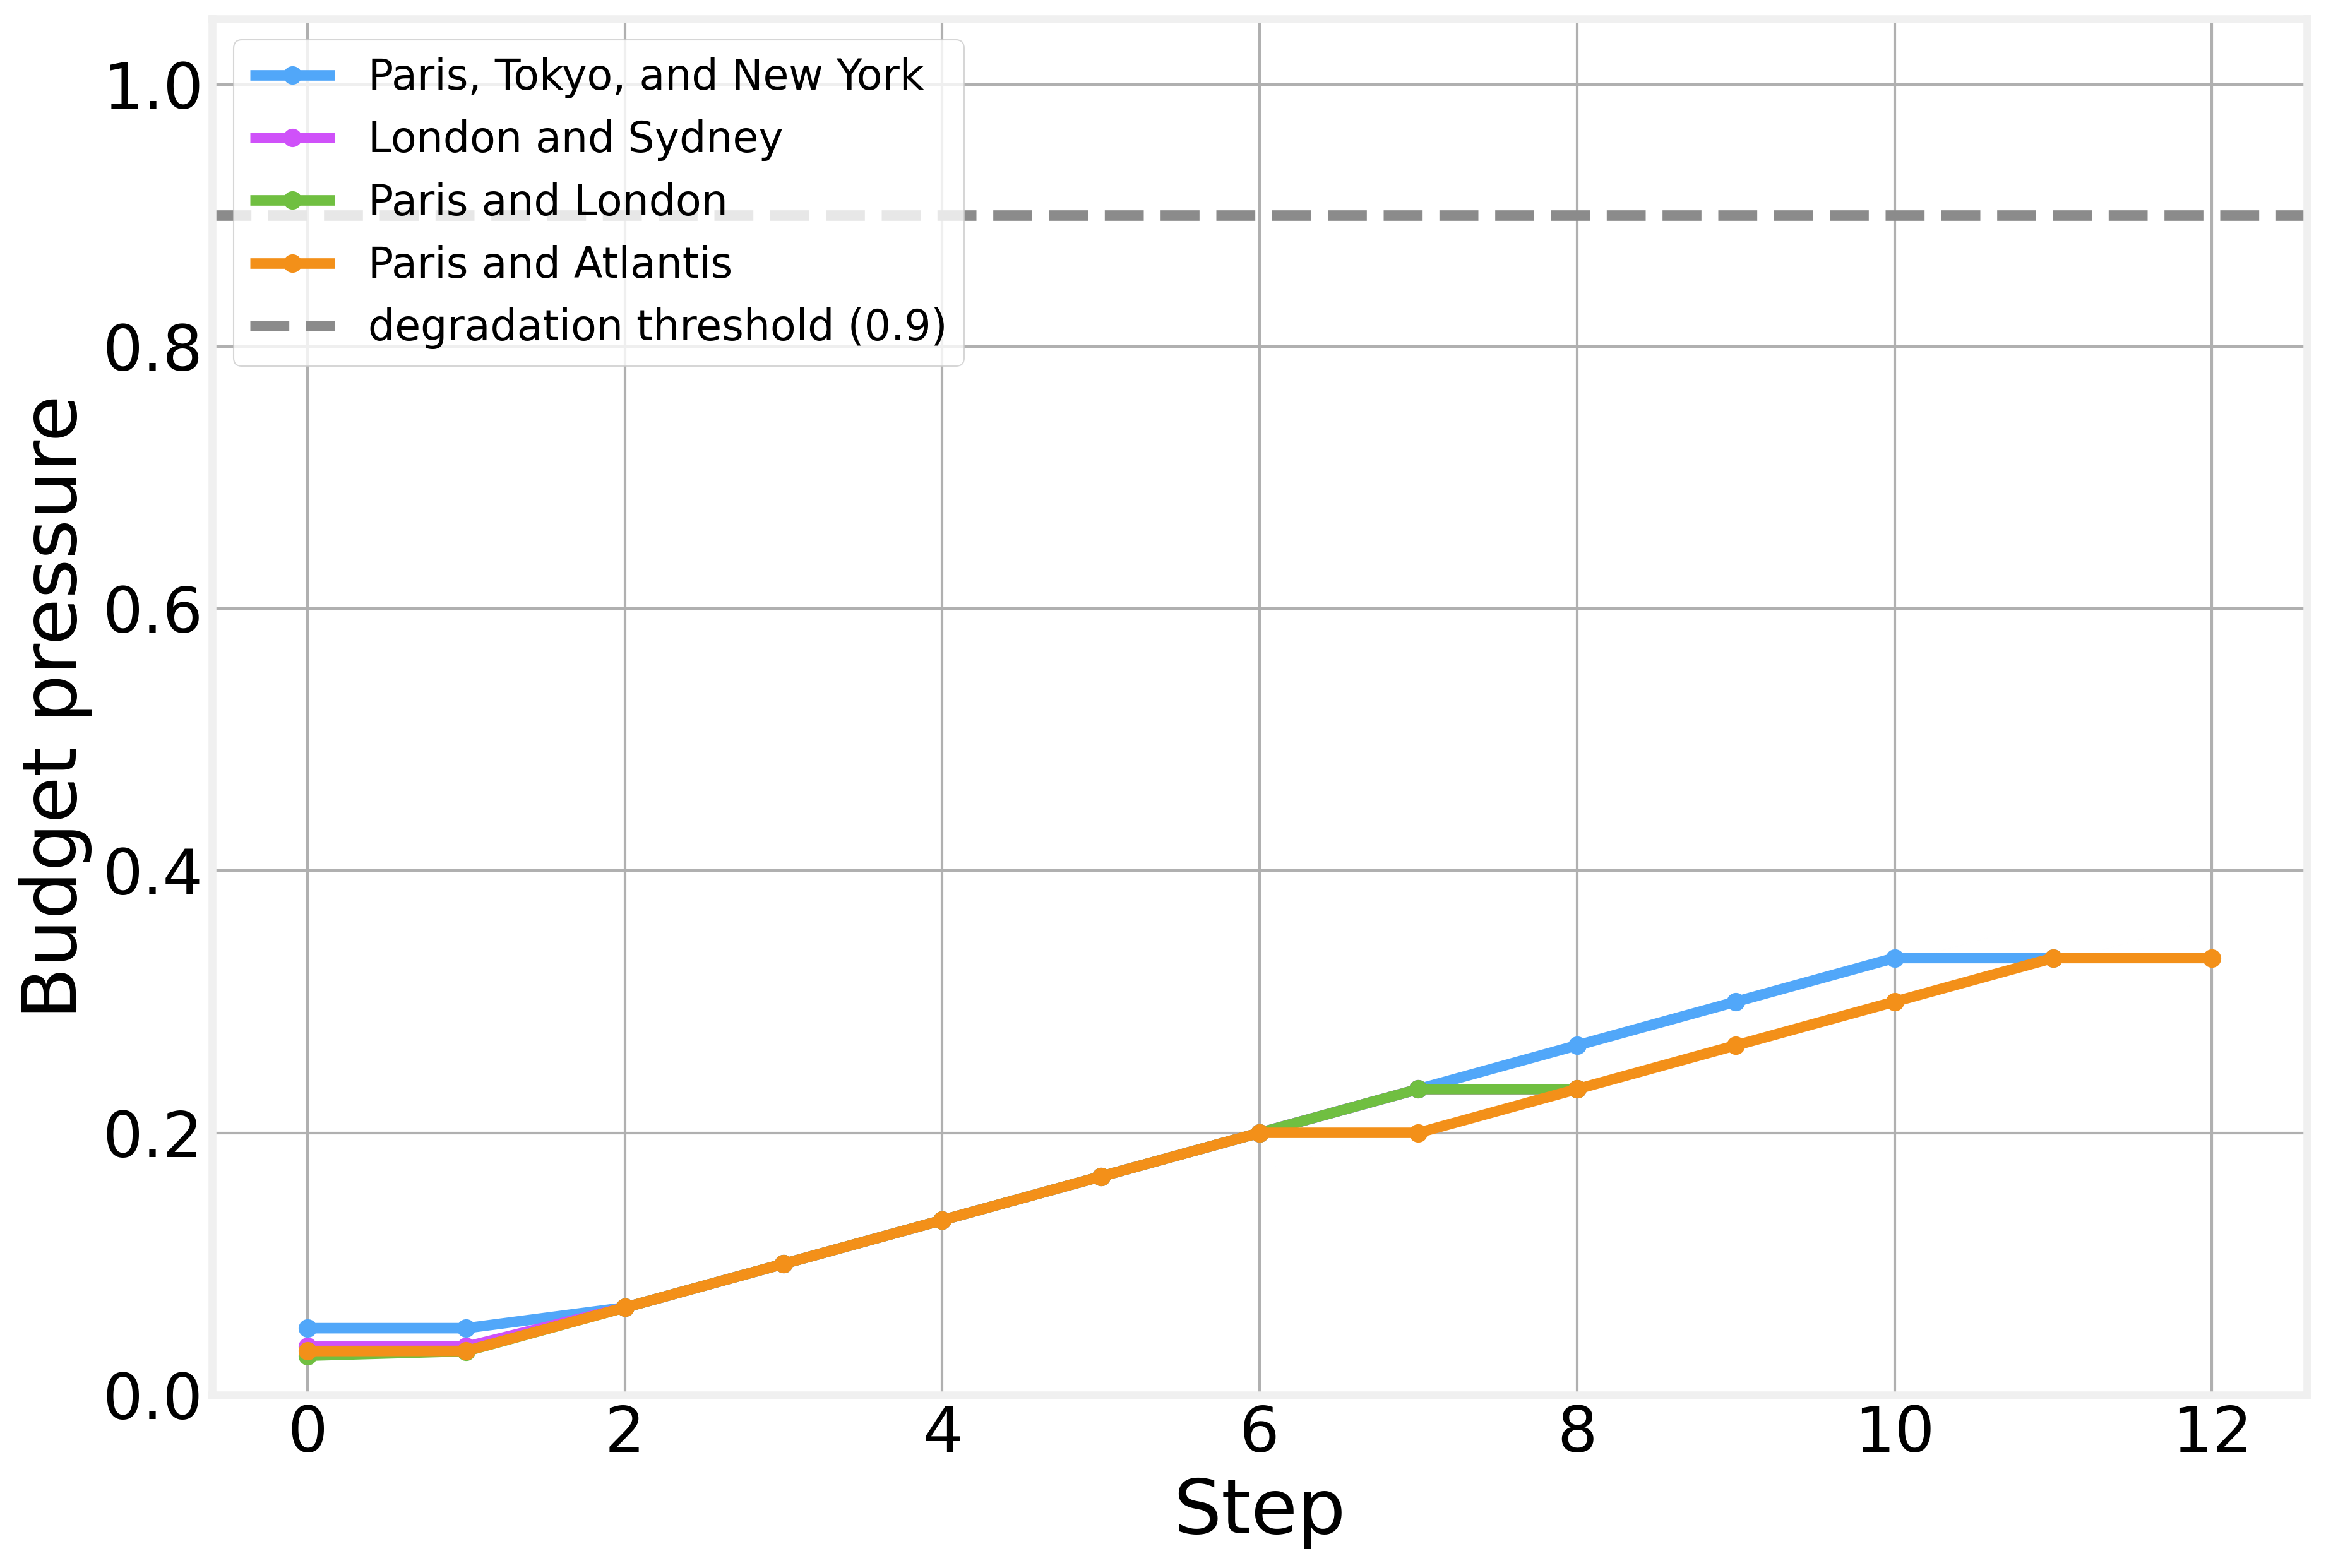

In [10]:
fig, ax = plt.subplots()
for label, run, color in zip(task_labels, eval_runs, colors):
    pressures = [e.budget_pressure for e in run.tracer.events]
    ax.plot(range(len(pressures)), pressures, marker="o", color=color, label=label)
ax.axhline(0.9, linestyle="--", color=colors[7], label="degradation threshold (0.9)")
ax.set_xlabel("Step")
ax.set_ylabel("Budget pressure")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=16)
plt.tight_layout()

### Reading the eval plots

- **Cost (Plot 1)** — failed runs are not free: a `failed_execute` run still pays for planning and for every tool call it made before giving up. The tier annotations show which rung of the verification ladder produced each verdict.
- **Time by role (Plot 2)** — worker segments dominate: LLM-backed tools are where wall-clock goes. The gap between stacked bar and diamond is the DAG executor's parallelism payoff.
- **Tokens by role (Plot 3)** — the Atlantis task carries an extra planner segment from the replan attempt. That's robustness, priced in tokens.
- **Budget pressure (Plot 4)** — all trajectories should stay well below 0.9 on this toy workload; production dashboards alert when a task class starts drifting upward.

In production these panels update on every CI run — the JSON trace is the durable artifact, the plots are just views over it.

---
## 4. Enhanced features: re-planning, real embeddings, and specialized workers

Sections 2–3 measured the harness as notebook 03 left it. This section closes three of the gaps that separate the teaching harness from production systems, with **minimal changes to the architecture** — demonstrating that good primitives make extensions cheap.

| Enhancement | Production motivation | What changes in code |
|---|---|---|
| Re-planning on failure | Unknown entities shouldn't abort the whole run | Orchestrator loop + `PlannerAgent.replan()` |
| Real embeddings | Bag-of-words retrieval misses paraphrases | `MemoryStore` + sentence-transformers |
| Specialized workers | Fetch and LLM tools need different rate limits | `FetcherAgent` / `WriterAgent` routing |

### 4.1 Re-planning on failure

**Scenario:** The user asks for a report including "Atlantis." The population lookup raises `KeyError: Unknown city`.

**Naive response:** Fail the entire run.

**Harness response:**

1. Worker marks the node `FAILED`
2. `classify_error()` returns `MISSING_INFO`
3. Orchestrator calls `planner.replan(goal, failed_dag)` with failure context
4. Planner emits a new DAG excluding Atlantis (or substituting known cities)
5. Worker executes the amended plan

**Why pass failure context to the planner?** Blind retry would reproduce the same error. Informed re-planning lets the LLM reason about alternatives — skip the city, ask for clarification, or use a fallback tool.

The demo below uses `GOAL_WITH_UNKNOWN` to trigger this path. Watch `replan_count` and the planner events in the trace.

In [11]:
# Test re-planning with an unknown city
orch_replan = Orchestrator(provider=llm, tools=TOOLS, memory=store, max_replans=2)

GOAL_WITH_UNKNOWN = (
    "Build a comparison report of Paris, Tokyo, and Atlantis covering "
    "population, timezone, and a narrative summary for each."
)
REQUIRED_WITH_UNKNOWN = ["paris", "tokyo", "atlantis"]

result_replan = asyncio.run(orch_replan.run(GOAL_WITH_UNKNOWN, REQUIRED_WITH_UNKNOWN))

print(f"Status:        {result_replan.status}")
print(f"Replan count:  {result_replan.replan_count}")
print(f"Verdict:       passed={result_replan.verdict.passed if result_replan.verdict else 'n/a'}")
print(f"Tokens used:   {result_replan.budget.tokens_used}")
print(f"Tool calls:    {result_replan.budget.tool_calls_used}")
print()
print("--- REPORT ---")
print(result_replan.report if result_replan.report else "No report generated")
print()
print("--- TRACE SUMMARY ---")
planner_events = [e for e in result_replan.tracer.events if e.role == "planner"]
print(f"Planning attempts: {len(planner_events)}")
for i, ev in enumerate(planner_events):
    print(f"  Attempt {i+1}: {ev.action['type']} → {ev.result['n_nodes']} nodes")

Status:        failed_verify_replanned_1x
Replan count:  1
Verdict:       passed=False
Tokens used:   1802
Tool calls:    16

--- REPORT ---
# City Comparison Report

## Paris
- **Population:** 2,100,000
- **Timezone:** CET (Central European Time)
- **Country:** France

## Tokyo
- **Population:** 13,960,000
- **Timezone:** JST (Japan Standard Time)
- **Country:** Japan

## Key Differences
Tokyo has a significantly larger population than Paris, with approximately 6.6 times more residents. The cities operate in different timezones, with Tokyo being 9 hours ahead of Paris during standard time.

--- TRACE SUMMARY ---
Planning attempts: 2
  Attempt 1: initial_plan → 10 nodes
  Attempt 2: replan → 7 nodes


### Interpreting the re-plan demo

This run asks for **Atlantis** — not in `CITY_FACTS`. Expected behavior:

1. First plan includes Atlantis fetch nodes
2. Worker hits `KeyError: Unknown city: 'atlantis'` → node `FAILED`
3. `classify_error` → `MISSING_INFO`
4. Orchestrator calls `replanner` with failure context
5. Second plan excludes Atlantis (or only known cities)
6. Run completes with partial report; `replan_count >= 1`

This is **graceful degradation**: deliver value instead of aborting on bad input. The next two cells make the recovery *visible* — first the amended DAG that actually executed, then the full per-step trace with both planner events.

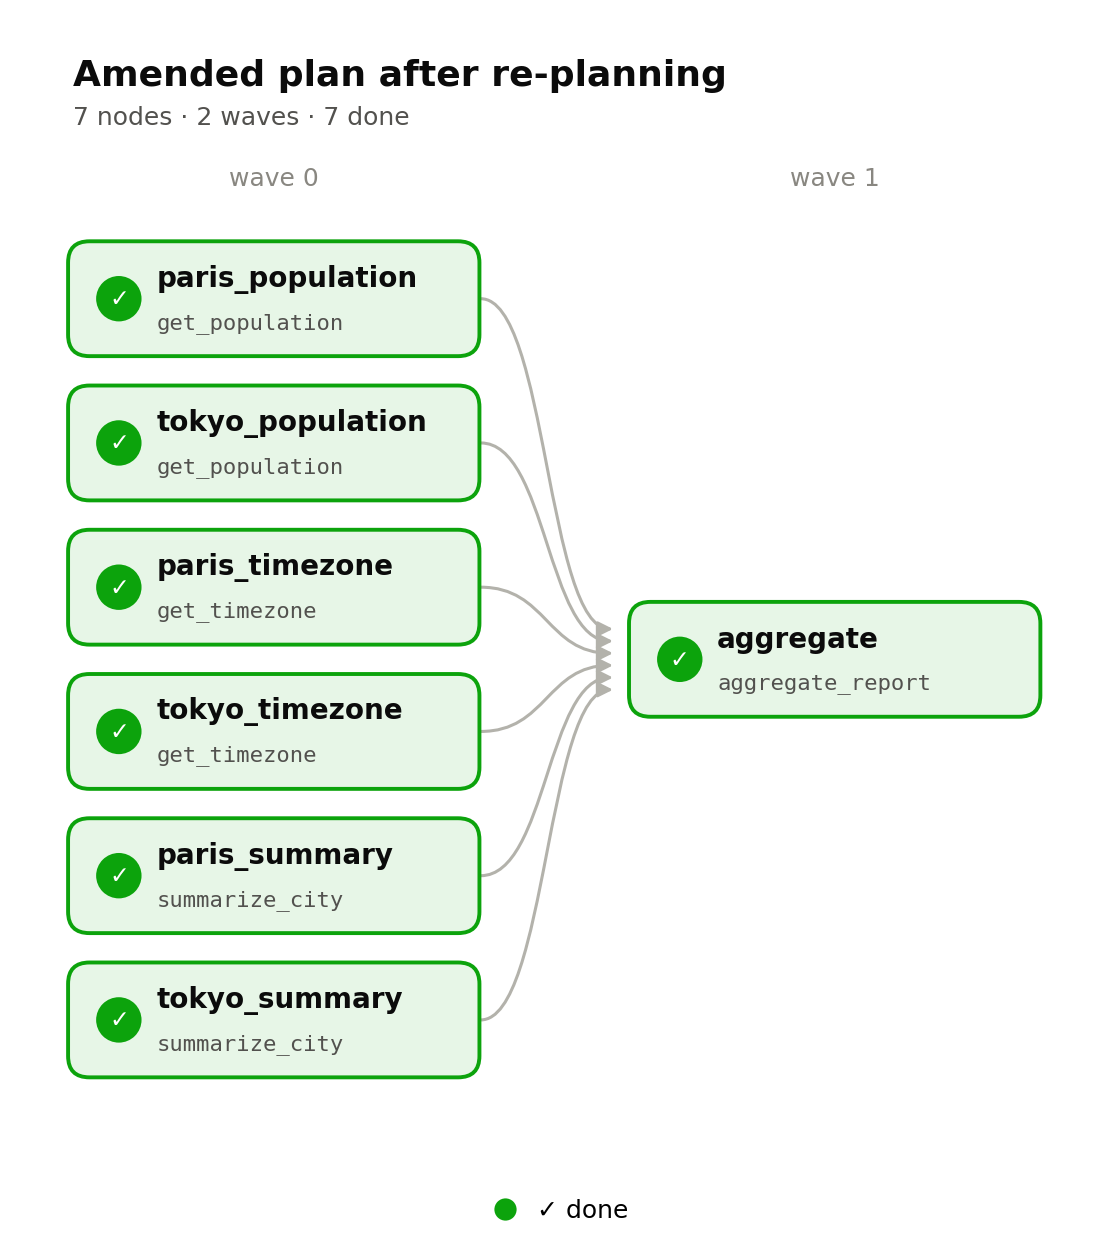

In [12]:
# Visualize the amended DAG — the plan that actually executed after the replan
result_replan.dag.plot("replan_dag.png", title="Amended plan after re-planning")

Image("replan_dag.png")

The per-step trace tells the whole story in one picture: every event on its own row, colored by role. Look for the second planner row partway down — everything above it belongs to the failed first plan, everything below to the amended one.

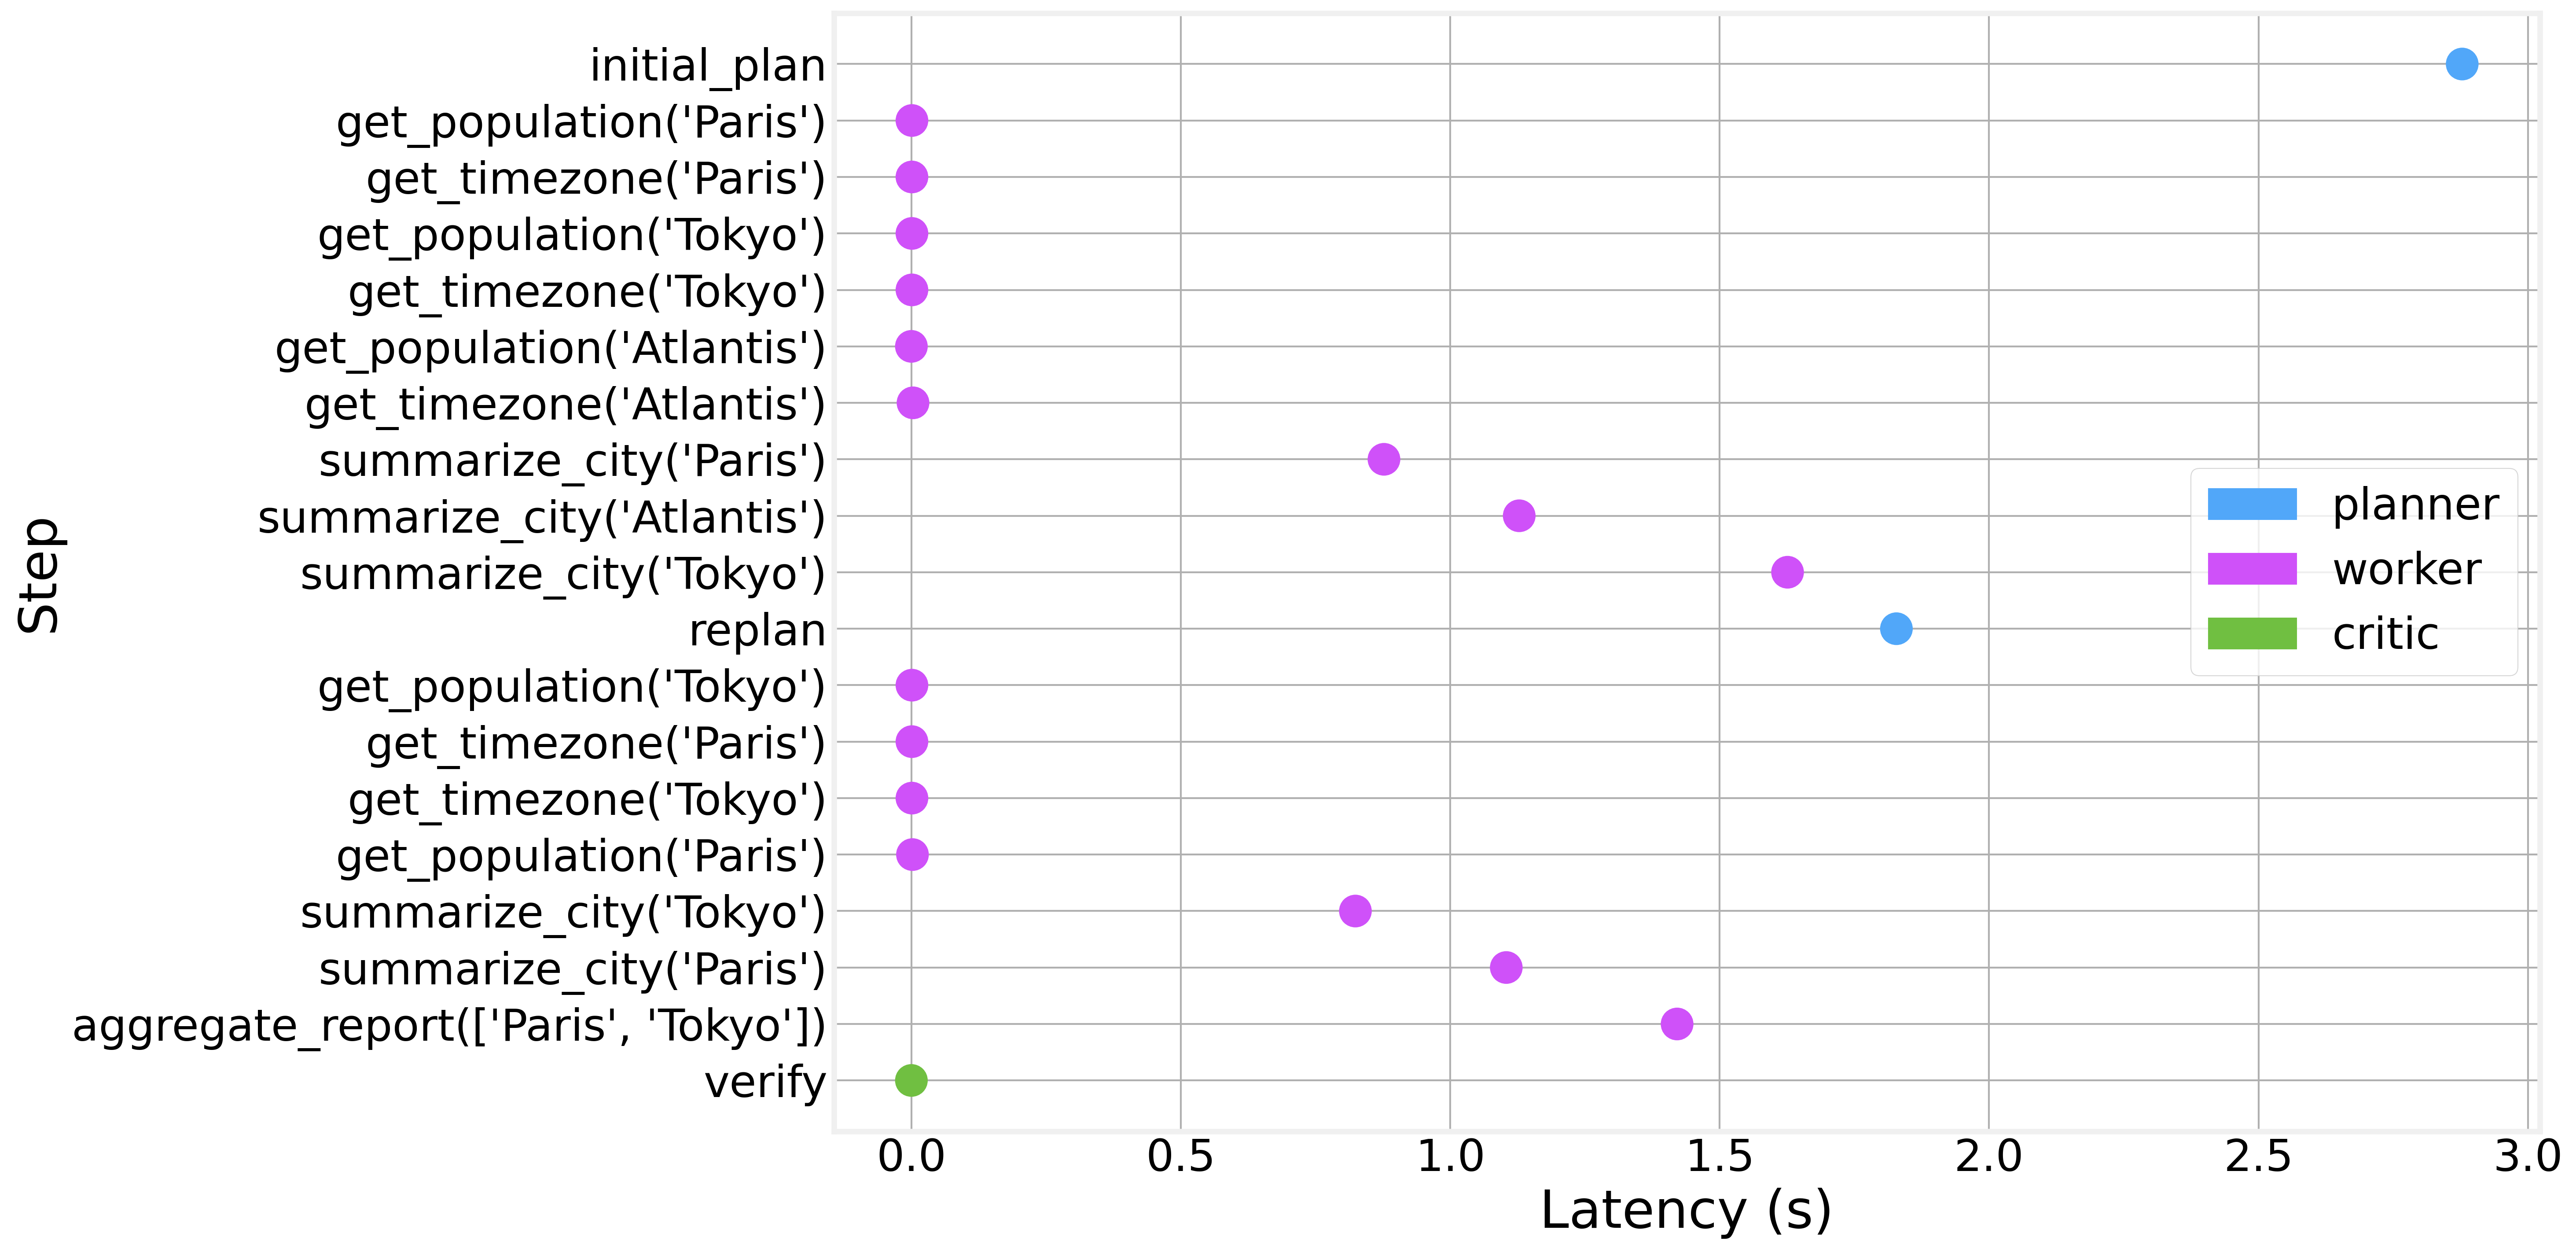

In [13]:
events = result_replan.tracer.dump()


def event_labels(events):
    labels = []
    for e in events:
        action = e.get("action", {})
        kind = action.get("type", "?")
        if kind == "tool_call":
            args = ", ".join(repr(v) for v in action.get("args", {}).values())
            labels.append(f"{action.get('tool')}({args})")
        else:
            labels.append(kind)
    return labels


latencies = np.array([e["latency_ms"] for e in events])
point_colors = [role_colors[e["role"]] for e in events]

fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(latencies / 1000, range(len(events)), color=point_colors, s=300)
ax.set_xlabel("Latency (s)")
ax.set_ylabel("Step")
ax.set_yticks(range(len(events)))
ax.set_yticklabels(event_labels(events))
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in role_colors.values()]
ax.legend(handles, role_colors.keys(), loc="center right")
ax.invert_yaxis()
plt.tight_layout()

### 4.2 Real Embeddings with sentence-transformers

**Why Jaccard isn't enough:** Similarity by word overlap fails when the query and memory use different vocabulary:

- Query: *"Tell me about famous landmarks in France"*
- Memory: *"Paris is known for the Eiffel Tower..."*
- Jaccard score ≈ 0 (no shared words except common stopwords)

**Embedding models** map text to dense vectors where paraphrases are nearby. We use `all-MiniLM-L6-v2` (384 dimensions, fast, good enough for retrieval demos).

### Design choices

- **Encode on `add()`** — pay embedding cost once at write time, not on every query
- **Cosine similarity at query time** — standard for normalized sentence embeddings
- **Automatic fallback** — if `sentence-transformers` isn't installed, Jaccard still works

The benchmark below runs identical queries against both stores and checks whether embeddings surface the expected memory. This is a minimal version of the retrieval evals you'd run before swapping memory backends in production.


In [14]:
# Compare Jaccard vs embedding retrieval over the same memory set
store_jaccard = MemoryStore(use_embeddings=False)
store_embeddings = MemoryStore(use_embeddings=USE_REAL_EMBEDDINGS)

# Populate with diverse memories
memories = [
    ("Paris is known for the Eiffel Tower and French cuisine.", "semantic"),
    ("Tokyo has the busiest train stations in the world.", "semantic"),
    ("New York is famous for Times Square and Broadway.", "semantic"),
    ("Previously compared European cities and found timezone data was missing.", "episodic"),
    ("Task comparing Asian cities succeeded with all population data.", "episodic"),
    ("London's Big Ben is an iconic landmark.", "semantic"),
    ("Sydney Opera House is a UNESCO World Heritage site.", "semantic"),
]

for content, kind in memories:
    store_jaccard.add(content, kind)
    store_embeddings.add(content, kind)

# Paraphrased queries, each with the keyword its ideal answer should contain
test_queries = [
    ("Tell me about famous landmarks in France", ["Paris is known for the Eiffel Tower"]),
    ("What happened when comparing cities in Europe?", ["Previously compared European cities"]),
    ("Information about Japanese cities", ["Tokyo has the busiest train stations"]),
]

for query, expected in test_queries:
    print(f"Query: {query}")
    for name, store_ in (("Jaccard", store_jaccard), ("Embeddings", store_embeddings)):
        results = store_.retrieve(query, k=2)
        hit = any(kw in m.content for m in results for kw in expected)
        marker = "✓" if hit else "✗"
        print(f"  {name:10s} {marker}  " + " | ".join(m.content[:45] for m in results))
    print()

MemoryStore: Using Jaccard similarity


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MemoryStore: Using sentence-transformers embeddings (all-MiniLM-L6-v2)
Query: Tell me about famous landmarks in France
  Jaccard    ✗  Tokyo has the busiest train stations in the w | New York is famous for Times Square and Broad
  Embeddings ✓  Paris is known for the Eiffel Tower and Frenc | London's Big Ben is an iconic landmark.

Query: What happened when comparing cities in Europe?
  Jaccard    ✗  Task comparing Asian cities succeeded with al | Tokyo has the busiest train stations in the w
  Embeddings ✓  Task comparing Asian cities succeeded with al | Previously compared European cities and found

Query: Information about Japanese cities
  Jaccard    ✗  Task comparing Asian cities succeeded with al | Previously compared European cities and found
  Embeddings ✓  Tokyo has the busiest train stations in the w | Task comparing Asian cities succeeded with al



### Interpreting the embedding benchmark

The side-by-side retrieval shows the cases that matter:

- Queries where **Jaccard misses** the relevant memory but embeddings rank it first — the vocabulary of the query ("landmarks in France") barely overlaps with the memory ("Eiffel Tower", "Paris"), so word overlap fails where semantic distance succeeds
- Cases where both agree — a sanity check that embeddings don't *lose* anything on easy queries

The heatmap below makes the comparison exhaustive: every query scored against every memory, under both similarity functions. The best score per row is bold — that's the memory each method would retrieve first.

**Production lesson:** never swap a retrieval backend without a labeled query set like this, even a tiny one.

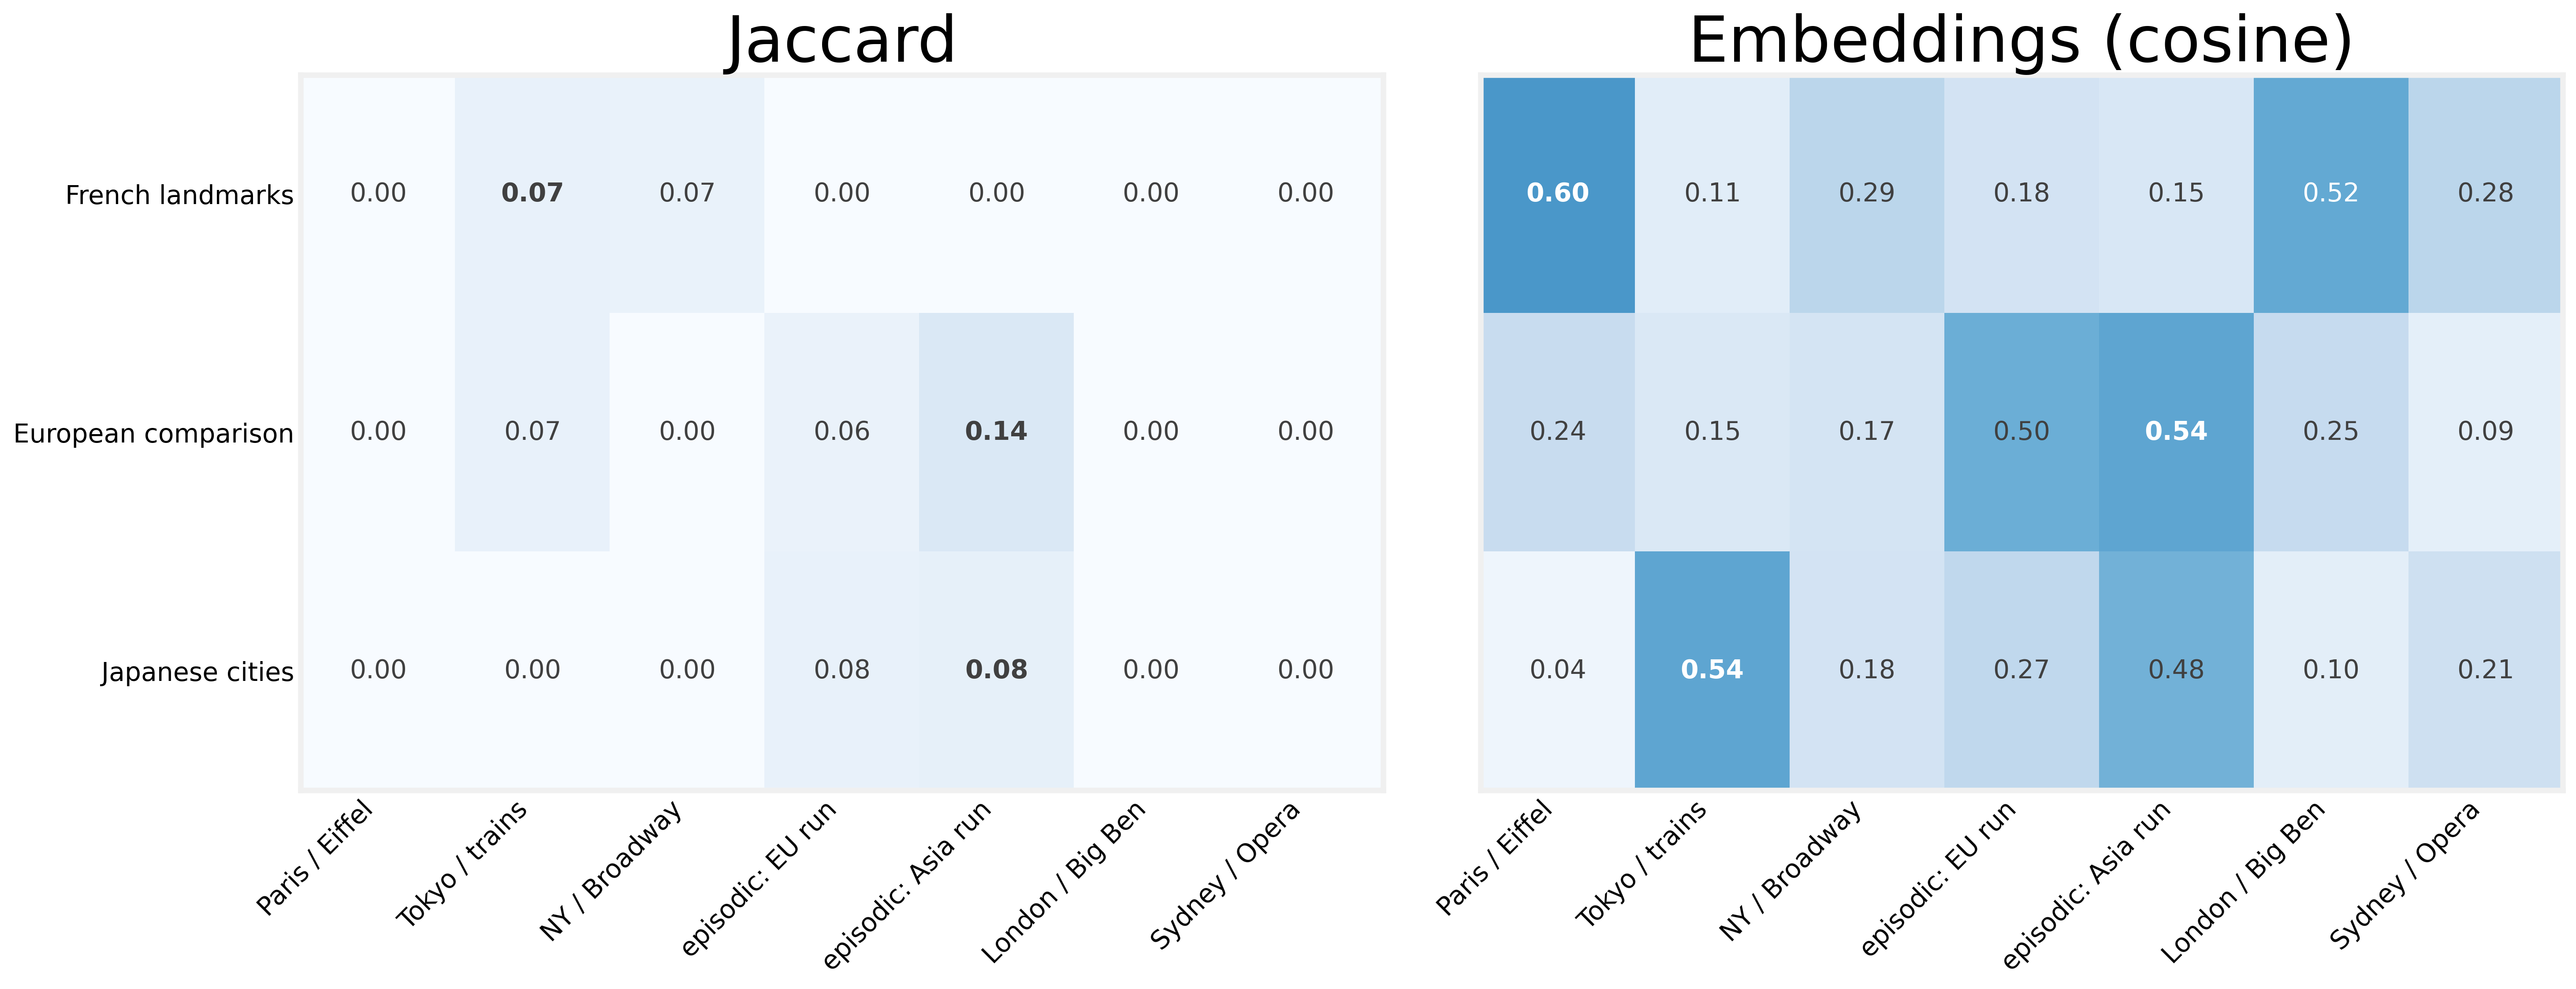

In [15]:
if USE_REAL_EMBEDDINGS:
    queries = [q for q, _ in test_queries]
    query_labels = ["French landmarks", "European comparison", "Japanese cities"]
    memory_labels = ["Paris / Eiffel", "Tokyo / trains", "NY / Broadway",
                     "episodic: EU run", "episodic: Asia run",
                     "London / Big Ben", "Sydney / Opera"]

    # Jaccard scores, straight from the harness helper
    jac = np.array([[dh._sim(q, m) for m, _ in memories] for q in queries])

    # Cosine scores, using the store's own encoder
    model = store_embeddings._model
    q_emb = model.encode(queries)
    m_emb = model.encode([m for m, _ in memories])
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    m_emb = m_emb / np.linalg.norm(m_emb, axis=1, keepdims=True)
    cos = q_emb @ m_emb.T

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    for ax, mat, title in ((axes[0], jac, "Jaccard"),
                           (axes[1], cos, "Embeddings (cosine)")):
        ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.grid(False)
        ax.set_title(title)
        ax.set_xticks(range(len(memory_labels)))
        ax.set_xticklabels(memory_labels, rotation=45, ha="right", fontsize=14)
        for i in range(mat.shape[0]):
            best = np.argmax(mat[i])
            for j in range(mat.shape[1]):
                ax.annotate(f"{mat[i, j]:.2f}", (j, i), ha="center", va="center",
                            fontsize=14,
                            color="white" if mat[i, j] > 0.5 else "0.25",
                            fontweight="bold" if j == best else "normal")
    axes[0].set_yticks(range(len(query_labels)))
    axes[0].set_yticklabels(query_labels, fontsize=14)
    plt.tight_layout()
else:
    print("sentence-transformers not installed — the heatmap needs the embedding backend")

### 4.3 Specialized Worker Agents

**Observation:** Not all tools have the same operational profile:

| Tool type | Latency | Rate limits | Failure modes |
|---|---|---|---|
| Lookups (`get_population`) | ~ms | Generous | Missing key |
| LLM tools (`summarize_city`) | seconds | Strict | Malformed JSON, content policy |

Running both through one semaphore (`MAX_CONCURRENT = 5`) treats them identically. Production systems **route by capability**:

- **`FetcherAgent`** — fast, idempotent lookups; higher concurrency OK
- **`WriterAgent`** — LLM-backed; lower concurrency, different retry policy

The unified `WorkerAgent` exposes the same `execute(dag)` interface but routes internally via `execute_dag_with_routing`. The orchestrator doesn't change — another benefit of compositional design.

Future extensions: `BrowserAgent`, `CodeAgent`, each with its own tool subset, semaphore, and trace tags.


In [16]:
class FetcherAgent:
    """Specialized worker for fast lookup tools (get_population, get_timezone)."""

    def __init__(self, tools: dict[str, TypedTool]):
        # Filter to only lookup tools
        self._tools = {
            name: tool for name, tool in tools.items()
            if name in ("get_population", "get_timezone")
        }

    async def execute(self, dag: PlanDAG,
                      on_step: Callable[[PlanNode, float], None] | None = None) -> None:
        """Execute only the nodes that use fetcher tools."""
        await execute_dag_filtered(dag, self._tools, self._can_handle, on_step=on_step)
    
    def _can_handle(self, node: PlanNode) -> bool:
        return node.tool in self._tools


class WriterAgent:
    """Specialized worker for LLM-backed composition tools (summarize_city, aggregate_report)."""

    def __init__(self, tools: dict[str, TypedTool]):
        # Filter to only LLM-backed tools
        self._tools = {
            name: tool for name, tool in tools.items()
            if name in ("summarize_city", "aggregate_report")
        }

    async def execute(self, dag: PlanDAG,
                      on_step: Callable[[PlanNode, float], None] | None = None) -> None:
        """Execute only the nodes that use writer tools."""
        await execute_dag_filtered(dag, self._tools, self._can_handle, on_step=on_step)
    
    def _can_handle(self, node: PlanNode) -> bool:
        return node.tool in self._tools


class WorkerAgent:
    """Unified worker that delegates to specialized agents based on tool type."""

    def __init__(self, tools: dict[str, TypedTool]):
        self._tools = tools
        self.fetcher = FetcherAgent(tools)
        self.writer = WriterAgent(tools)

    async def execute(self, dag: PlanDAG,
                      on_step: Callable[[PlanNode, float], None] | None = None) -> None:
        """Execute the DAG by routing nodes to specialized agents."""
        await execute_dag_with_routing(dag, self._tools, self.fetcher, self.writer, on_step=on_step)


async def execute_dag_filtered(dag: PlanDAG, tools: dict[str, TypedTool],
                                can_handle: Callable[[PlanNode], bool],
                                on_step: Callable[[PlanNode, float], None] | None = None):
    """Execute only nodes that pass the can_handle filter."""
    semaphore = asyncio.Semaphore(MAX_CONCURRENT)

    async def run_node(node: PlanNode) -> None:
        if not can_handle(node):
            return  # Skip nodes this agent can't handle
        
        node.status = NodeStatus.RUNNING
        node.attempt += 1
        async with semaphore:
            t0 = time.time()
            try:
                tool = tools[node.tool]
                node.result = await asyncio.to_thread(tool.run, node.args)
                node.status = NodeStatus.DONE
            except Exception as exc:
                node.error = f"{type(exc).__name__}: {exc}"
                node.status = NodeStatus.FAILED
            finally:
                if on_step:
                    on_step(node, time.time() - t0)

    while not dag.is_done():
        ready = [n for n in dag.ready_nodes() if can_handle(n)]
        if not ready:
            # Check if there are any pending nodes this agent can handle
            pending = [n for n in dag.nodes.values() 
                      if n.status == NodeStatus.PENDING and can_handle(n)]
            if not pending:
                break  # No more work for this agent
            # Dependencies not ready yet
            await asyncio.sleep(0.01)
            continue
        await asyncio.gather(*(run_node(n) for n in ready))


async def execute_dag_with_routing(dag: PlanDAG, tools: dict[str, TypedTool],
                                   fetcher: FetcherAgent, writer: WriterAgent,
                                   on_step: Callable[[PlanNode, float], None] | None = None):
    """Execute DAG by routing to specialized agents, running them in parallel."""
    semaphore = asyncio.Semaphore(MAX_CONCURRENT)

    async def run_node(node: PlanNode, agent_name: str) -> None:
        node.status = NodeStatus.RUNNING
        node.attempt += 1
        async with semaphore:
            t0 = time.time()
            try:
                tool = tools[node.tool]
                node.result = await asyncio.to_thread(tool.run, node.args)
                node.status = NodeStatus.DONE
            except Exception as exc:
                node.error = f"{type(exc).__name__}: {exc}"
                node.status = NodeStatus.FAILED
            finally:
                if on_step:
                    on_step(node, time.time() - t0)

    while not dag.is_done():
        ready = dag.ready_nodes()
        if not ready:
            break
        
        # Route nodes to appropriate agents
        tasks = []
        for node in ready:
            if fetcher._can_handle(node):
                tasks.append(run_node(node, "fetcher"))
            elif writer._can_handle(node):
                tasks.append(run_node(node, "writer"))
            else:
                # Fallback: execute with any available tool
                tasks.append(run_node(node, "generic"))
        
        await asyncio.gather(*tasks)

In [17]:
# Route a mixed DAG through the unified worker, recording who handled what and when
test_dag_mixed = PlanDAG.from_json({
    "nodes": [
        {"id": "pop_paris", "tool": "get_population", "args": {"city": "paris"}, "deps": []},
        {"id": "tz_paris", "tool": "get_timezone", "args": {"city": "paris"}, "deps": []},
        {"id": "sum_paris", "tool": "summarize_city", "args": {"city": "paris"}, "deps": []},
        {"id": "pop_tokyo", "tool": "get_population", "args": {"city": "tokyo"}, "deps": []},
        {"id": "tz_tokyo", "tool": "get_timezone", "args": {"city": "tokyo"}, "deps": []},
        {"id": "sum_tokyo", "tool": "summarize_city", "args": {"city": "tokyo"}, "deps": []},
        {"id": "agg", "tool": "aggregate_report",
         "args": {"cities": ["paris", "tokyo"]},
         "deps": ["pop_paris", "tz_paris", "sum_paris", "pop_tokyo", "tz_tokyo", "sum_tokyo"]},
    ]
})

timeline: dict[str, dict] = {}
t_run0 = time.time()


def track_agent(node: PlanNode, wall_s: float) -> None:
    agent = ("FetcherAgent" if node.tool in ("get_population", "get_timezone")
             else "WriterAgent")
    now = time.time() - t_run0
    timeline[node.id] = {"agent": agent, "start": now - wall_s, "end": now}


worker = WorkerAgent(TOOLS)
asyncio.run(worker.execute(test_dag_mixed, on_step=track_agent))

for nid, t in sorted(timeline.items(), key=lambda kv: kv[1]["start"]):
    print(f"{nid:10s} → {t['agent']:12s} ({(t['end'] - t['start']) * 1000:8.1f} ms)")

fetch_count = sum(1 for t in timeline.values() if t["agent"] == "FetcherAgent")
write_count = sum(1 for t in timeline.values() if t["agent"] == "WriterAgent")
print(f"\nRouting: {fetch_count} fetch operations, {write_count} LLM-backed operations")

pop_paris  → FetcherAgent (     0.7 ms)
tz_paris   → FetcherAgent (     0.6 ms)
sum_paris  → WriterAgent  (   901.7 ms)
pop_tokyo  → FetcherAgent (     0.6 ms)
tz_tokyo   → FetcherAgent (     0.6 ms)
sum_tokyo  → WriterAgent  (  1445.0 ms)
agg        → WriterAgent  (  2553.5 ms)

Routing: 4 fetch operations, 3 LLM-backed operations


### Interpreting worker routing

The demo tracks which specialized agent handled each node:

- **FetcherAgent** — `get_population`, `get_timezone` (cheap, sync, no LLM)
- **WriterAgent** — `summarize_city`, `aggregate_report` (LLM-backed)

The unified `WorkerAgent` preserves the orchestrator interface while enabling independent tuning (concurrency limits, retries, monitoring tags). The timeline below shows *why* the split matters operationally: fetch nodes finish in milliseconds while writer nodes own the critical path — they are the ones worth giving their own semaphore and retry policy.

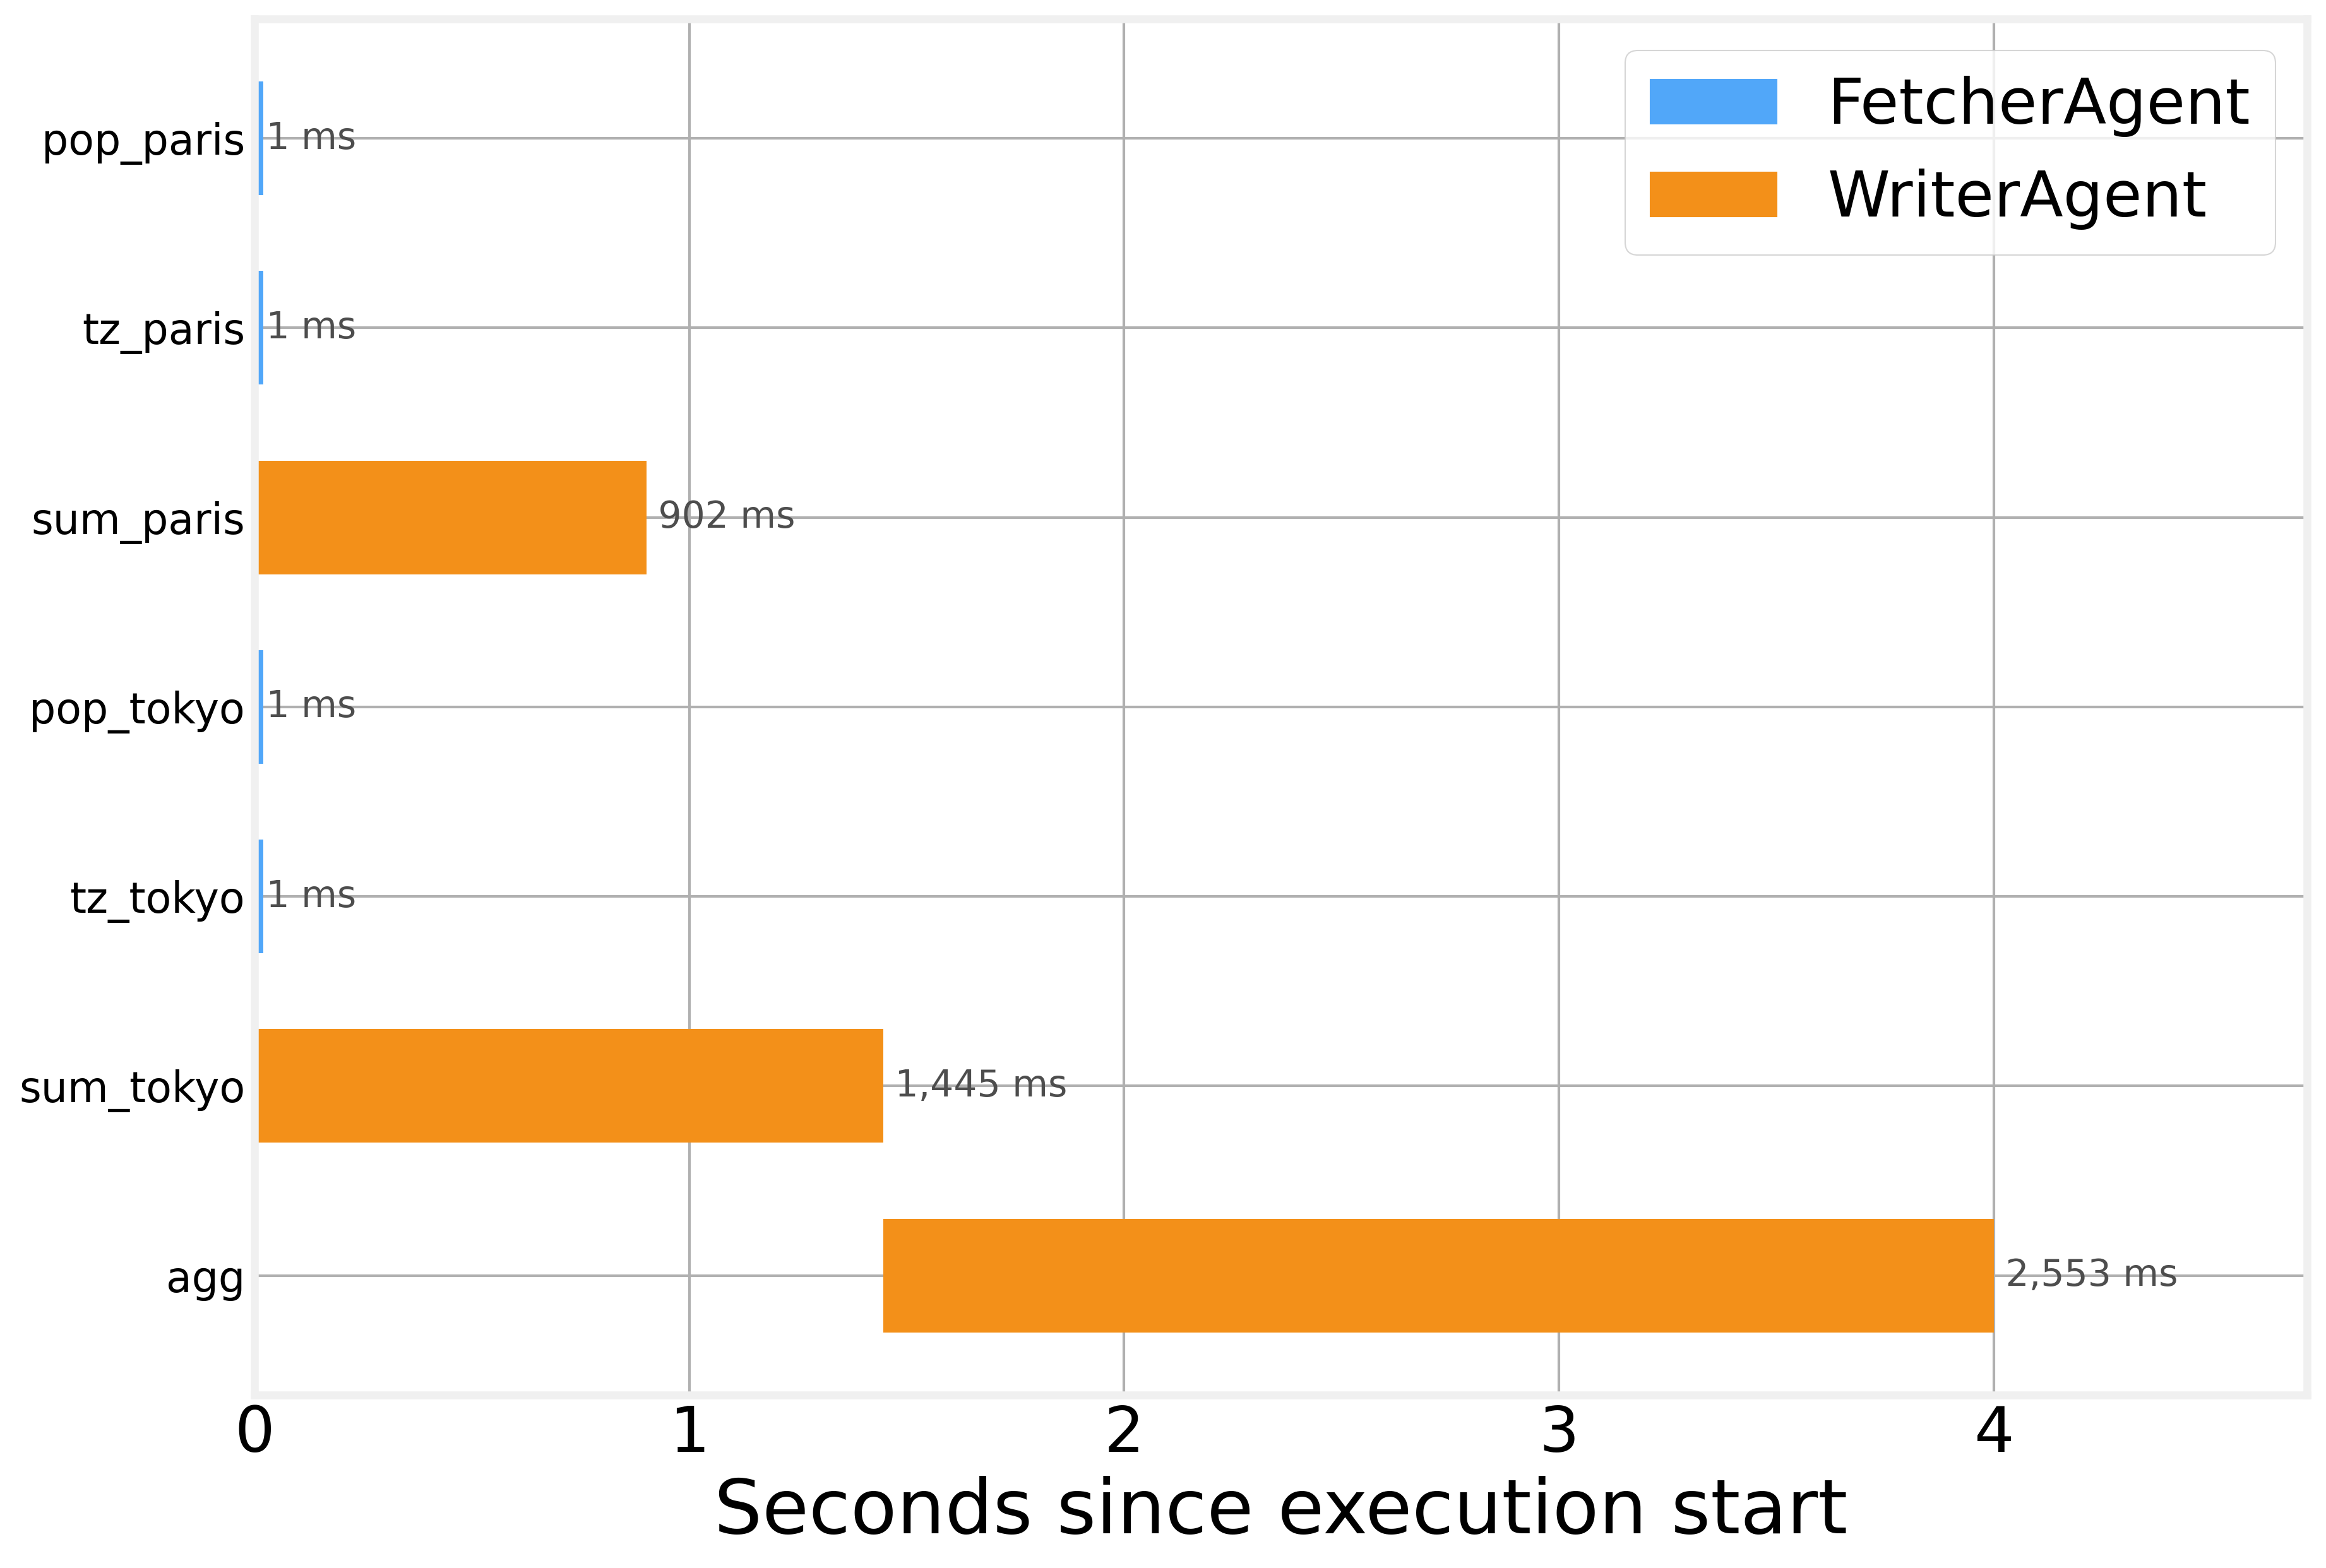

In [18]:
order = sorted(timeline, key=lambda nid: timeline[nid]["start"])
agent_colors = {"FetcherAgent": colors[0], "WriterAgent": colors[3]}

fig, ax = plt.subplots()
for y, nid in enumerate(order):
    t = timeline[nid]
    duration = t["end"] - t["start"]
    # enforce a minimum drawn width so ~ms fetches stay visible next to LLM calls
    ax.barh(y, max(duration, 0.02), left=t["start"], height=0.6,
            color=agent_colors[t["agent"]])
    ax.annotate(f" {duration * 1000:,.0f} ms", (t["end"], y),
                va="center", fontsize=14, color="0.3")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=16)
ax.invert_yaxis()
ax.set_xlabel("Seconds since execution start")
ax.set_xlim(0, max(t["end"] for t in timeline.values()) * 1.18)  # room for labels
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in agent_colors.values()]
ax.legend(handles, agent_colors.keys(), loc="upper right")
plt.tight_layout()

### Summary of enhancements

All three enhancements are now implemented and visualized:

1. **Re-planning on failure**
   - Orchestrator detects `MISSING_INFO` and loops through `planner.replan()`
   - Configurable `max_replans` (default: 2) prevents infinite replan cycles
   - Failure context (node id, tool, args, error) informs the amended DAG
   - `RunResult.replan_count` makes robustness measurable in evals

2. **Real embeddings**
   - `MemoryStore(use_embeddings=True)` loads `all-MiniLM-L6-v2`
   - Cosine similarity over 384-dim vectors; Jaccard fallback if unavailable
   - The similarity heatmap quantifies the retrieval quality improvement

3. **Specialized worker agents**
   - `FetcherAgent` / `WriterAgent` with tool-type routing
   - Same orchestrator interface; independent scaling knobs per agent class
   - The execution timeline shows writers owning the critical path

These enhancements move the harness closer to production systems while preserving the core lesson: **build small primitives, compose them, measure the result**.

---
## 5. What we built and what's next

Across notebooks 01, 03, and 04 we took a ~35-line loop and layered on production-shaped primitives:

| Layer | Component | Key benefit |
|---|---|---|
| Interface | Typed tools + Pydantic | One schema for validation and LLM introspection |
| Execution | DAG + asyncio | Parallelism without rewriting tools |
| Context | Multi-tier memory | Relevant history under a hard budget |
| Quality | Verification hierarchy | Cheap checks first, LLM judge last |
| Organization | Planner / Worker / Critic | Testable, swappable roles |
| Operations | Budget + recovery | Graceful degradation, not hard crashes |
| Measurement | Tracer + eval harness | Debuggable, regression-testable |

### The compositional payoff

None of these pieces *require* the others — but they **compose**:

- Add a tool → update `TOOLS` dict → planner auto-sees new schema
- Tighten verification → change `verify_report()` → eval suite catches regressions
- Swap LLM backend → change one line (`BACKEND = ...`) → entire harness reruns

That's the difference between a demo script and an **extensible harness**.

### What this still doesn't do

- **Persistent memory** — `MemoryStore` is in-process; production uses Chroma, Weaviate, or pgvector with durable embeddings
- **Prompt-injection defenses** — tool outputs are trusted as instructions; sandbox them as data in production
- **Human-in-the-loop** — irreversible actions should gate on human approval
- **Exact cost accounting** — we estimate tokens from character counts; wire up real SDK usage metadata
- **Richer multi-agent patterns** — debate, specialist pipelines, hierarchical planners

Section 4 closed three earlier gaps the same way you would close these: pick a gap, add a small typed component, and let the eval suite — and its plots — confirm nothing regressed.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>